**THE CATHOLIC UNIVERSITY OF EASTERN AFRICA**

**FACULTY OF SCIENCE**

**DEPARTMENT OF COMPUTER SCIENCE**

**UNIT: CMT 429**

**UNIT TITLE: INTRODUCTION TO DATA SCIENCE**

**LECTURER:**

Mr. David Gichohi Maina

**STUDENT:**
- DIANA OLULO - 1046050
- ISAAC KINYANJUI NGUGI - 1049049
- JOSPHINE WERE - 1049083
- ESTHER TAIFA - 1049093
- BRAYAN MWANGI -1049399
- ABIGAEL KIRIMI 1049507

# Phase 2 Project
- Domain: Business (Bank Marketing)
- Dataset: [Bank Marketing Dataset (UCI Machine Learning Repository)](https://archive.ics.uci.edu/dataset/222/bank+marketing)
- Github: [DS_Avengers_Bank_Marketing](https://github.com/iamisaackn/DS_Avengers_Bank_Marketing)

## Project Overview
This project focuses on using classification and regression techniques to analyze the Bank Marketing dataset from a
Portuguese banking institution. The dataset captures results of direct marketing campaigns (via phone calls) where the
main goal was to determine whether a client would subscribe to a term deposit. Using the R programming language,
we aim to build predictive models that will support decision-making in future marketing campaigns.

## Business Understanding
**Business Problem**

Banks spend significant resources on marketing campaigns, but most calls end without success. This leads to wasted
time, money, and reduced customer trust. The main problem is how to predict which clients are more likely to
subscribe to a term deposit, so that campaigns can be more targeted and cost-effective.

**Stakeholders**

- Bank management: Needs insights to improve campaign efficiency.
- Marketing teams: Want to know which customers to prioritize.
- Customers: Benefit from receiving more relevant and personalized offers.

## Research Questions
1. What customer demographic and financial characteristics influence subscription decisions?
2. How do campaign-related variables affect customer response?
3. Can we build a model that accurately predicts whether a client will subscribe to a term deposit?
4. Which features are the most important for prediction?

## Justification
The need for predictive modeling in banking is crucial because it reduces unnecessary calls, improves customer
experience, and increases return on investment in marketing. Data science provides tools to analyze historical data and
develop models that support smarter decision-making

## Data Description
- Source: UCI Machine Learning Repository – Bank Marketing Dataset.
- Instances: 45,211 records (depending on dataset version used).
- Key Features: Age, job, marital status, education, default, balance, housing loan, personal loan, contact type,
campaign details, and previous campaign outcomes.
- Target Variable: y (binary: “yes” = client subscribed, “no” = client did not subscribe).
- Data Type: Mix of categorical, integer, and binary features.
- Missing Values: Minimal, mostly in categorical variables such as “pdays” and “poutcome”.

## Objectives
**Main Objective**
To build a predictive classification model that determines whether a client will subscribe to a term deposit.

**Specific Objectives**
1. Perform data preprocessing (cleaning, handling missing values, encoding).
2. Conduct exploratory data analysis (EDA) to identify trends and patterns.
3. Provide conclusions and recommendations for banking decision-makers.

## Exploratory Data Analysis (EDA)
**Univariate Analysis (Expected):**
- Distribution of age, balance, campaign contacts.
- Frequency of categorical variables such as job type, marital status, and education.

**Bivariate Analysis (Expected):**
- Relationship between y (subscription) and independent features.
- Example: Subscription rate vs. education level, or vs. contact type.

**Multivariate Analysis (Expected):**
- Interaction between multiple features such as job, education, and balance in predicting y.
- Use of correlation plots and dimensionality reduction techniques.

## Dataset Selection Justification

In this project, we used the `bank-additional-full.csv` dataset and chose not to use `bank.csv`, `bank-full.csv`, or `bank-additional.csv`. The reason is that both `bank.csv` and `bank-additional.csv` are only 10% of the full data taken from `bank-full.csv` and `bank-additional-full.csv`, respectively.

We selected `bank-additional-full.csv` because it is a more complete and updated version of the original dataset. It includes five extra features related to the economy, such as employment rate and consumer confidence. These additional details help us better understand how external factors may affect customer decisions.

Using the full dataset gives us more accurate results and stronger insights for building predictive models.

In [2]:
# install.packages("dplyr")
library(dplyr) # Data wrangling
# install.packages("purrr")
library(purrr)
# install.packages("ggplot2")
library(ggplot2)     # Data visualization
# install.packages("htmlwidgets")
# install.packages("plotly")
library(plotly)
# install.packages("ggmosaic")
library(ggmosaic)
# install.packages("psych")
library(psych)
# install.packages("corrplot")
library(corrplot) # Correlation visualization
# install.packages("vcd")
library(vcd)  # for assocstats (Cramér’s V)

In [3]:
# Load the dataset
data <- read.csv("data/bank-additional-full.csv", header = TRUE)

In [4]:
# Check dimensions (rows, columns)
dim(data)

[1] 41188    21

**Dimensions**: 21 columns (Features) and 41,188 rows.

In [5]:
# View the first rows
head(data)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,⋯,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
1,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,⋯,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,57,services,married,high.school,unknown,no,no,telephone,may,mon,⋯,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,37,services,married,high.school,no,yes,no,telephone,may,mon,⋯,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,⋯,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
5,56,services,married,high.school,no,no,yes,telephone,may,mon,⋯,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
6,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,⋯,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [6]:
# Summarizing Data
summary(data)

      age            job              marital           education        
 Min.   :17.00   Length:41188       Length:41188       Length:41188      
 1st Qu.:32.00   Class :character   Class :character   Class :character  
 Median :38.00   Mode  :character   Mode  :character   Mode  :character  
 Mean   :40.02                                                           
 3rd Qu.:47.00                                                           
 Max.   :98.00                                                           
   default            housing              loan             contact         
 Length:41188       Length:41188       Length:41188       Length:41188      
 Class :character   Class :character   Class :character   Class :character  
 Mode  :character   Mode  :character   Mode  :character   Mode  :character  
                                                                            
                                                                            
                    

**Dataset Overview**
- Size: 41,188 observations
- Structure: Mix of numeric and categorical variables

**Demographics**
- Age: Ranges from 17 to 98 years; average age is 40
- Job, Marital Status, Education: All are categorical with varied entries

**Financial Attributes**
- Default, Housing, Loan: Categorical indicators of financial status
- Contact Method: Categorical (e.g., phone, cellular)

**Campaign Details**
- Month & Day of Week: Categorical indicators of contact timing
- Duration: Call duration ranges from 0 to 4918 seconds median is 180 seconds
- Campaign: Number of contacts per client ranges from 1 to 56

**Historical & Economic Indicators**
- Pdays: Mostly 999 (indicating no prior contact)
- Previous Contacts: Mostly 0, max is 7
- Poutcome: Outcome of previous marketing campaigns (categorical)
- Economic Variables:
  - Employment Variation Rate: Avg ~0.08
  - Consumer Price Index: Avg ~93.58
  - Consumer Confidence Index: Avg ~-40.5
  - Euribor 3-month Rate: Avg ~3.62
  - Number of Employees: Avg ~5167

**Target Variable**
- y: Indicates if the client subscribed to a term deposit (binary categorical)

In [7]:
# View data set structure and data types
str(data)

'data.frame':	41188 obs. of  21 variables:
 $ age           : int  56 57 37 40 56 45 59 41 24 25 ...
 $ job           : chr  "housemaid" "services" "services" "admin." ...
 $ marital       : chr  "married" "married" "married" "married" ...
 $ education     : chr  "basic.4y" "high.school" "high.school" "basic.6y" ...
 $ default       : chr  "no" "unknown" "no" "no" ...
 $ housing       : chr  "no" "no" "yes" "no" ...
 $ loan          : chr  "no" "no" "no" "no" ...
 $ contact       : chr  "telephone" "telephone" "telephone" "telephone" ...
 $ month         : chr  "may" "may" "may" "may" ...
 $ day_of_week   : chr  "mon" "mon" "mon" "mon" ...
 $ duration      : int  261 149 226 151 307 198 139 217 380 50 ...
 $ campaign      : int  1 1 1 1 1 1 1 1 1 1 ...
 $ pdays         : int  999 999 999 999 999 999 999 999 999 999 ...
 $ previous      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ poutcome      : chr  "nonexistent" "nonexistent" "nonexistent" "nonexistent" ...
 $ emp.var.rate  : num  1.1 1.1 1.1 1

**Attribute Description**

***Bank Client Information***: These features describe the personal and financial background of each client:
- `age`: Client’s age (numeric)
- `job`: Type of job (e.g., admin, technician, student, retired, unknown)
- `marital`: Marital status (e.g., married, single, divorced/widowed, unknown)
- `education`: Education level (e.g., basic, high school, university, professional course, unknown)
- `default`: Whether the client has credit in default (yes, no, unknown)
- `housing`: Whether the client has a housing loan (yes, no, unknown)
- `loan`: Whether the client has a personal loan (yes, no, unknown)

***Last Contact Details (Current Campaign)***: These features describe the last time the client was contacted during the current marketing campaign:
- `contact`: Communication type used (cellular or telephone)
- `month`: Month of last contact (e.g., jan, feb, mar, …, dec)
- `day_of_week`: Day of the week of last contact (e.g., mon, tue, wed, thu, fri)
- `duration`: Duration of the last contact in seconds (numeric) Note: This feature strongly influences the outcome but is only known after the call. For realistic modeling, it shall be excluded.

***Campaign History***: These features track how often and when the client was contacted:
- `campaign`: Number of contacts during the current campaign (includes last contact)
- `pdays`: Days since the client was last contacted in a previous campaign (999 means never contacted)
- `previous`: Number of contacts before the current campaign
- `poutcome`: Outcome of the previous campaign (failure, success, nonexistent)

***Social and Economic Indicators***: These features reflect the broader economic environment at the time of contact:
- `emp.var.rate`: Employment variation rate (quarterly)
- `cons.price.idx`: Consumer price index (monthly)
- `cons.conf.idx`: Consumer confidence index (monthly)
- `euribor3m`: Euribor 3-month interest rate (daily)
- `nr.employed`: Number of employees in the economy (quarterly)

***Target Variable***
- `y`: Whether the client subscribed to a term deposit (yes or no)

## Data Preprocessing

In [8]:
# Count missing values per column
colSums(is.na(data))

age            job        marital      education        default 
             0              0              0              0              0 
       housing           loan        contact          month    day_of_week 
             0              0              0              0              0 
      duration       campaign          pdays       previous       poutcome 
             0              0              0              0              0 
  emp.var.rate cons.price.idx  cons.conf.idx      euribor3m    nr.employed 
             0              0              0              0              0 
             y 
             0

**Missing Values**: There are no visible missing values except some categorical features contain missing values labeled as `"unknown"`. These can be handled by:
- Treating `"unknown"` as a valid category
- Removing affected rows
- Using imputation techniques to fill in missing data

In [9]:
# Count target variabl4e values
table(data$y)


   no   yes 
36548  4640 

**Target Variable**: 4640 clients subscribed to a term deposit while 36548 did not.

**Remove Unnecessary Columns**
- 'duration' since it's only known after the call

In [10]:
# Remove 'duration'
data$duration <- NULL

**Rename Columns** for clarity

In [11]:
# Rename columns
data <- data %>%
  rename(
    marital_status = marital,
    education_level = education,
    has_default = default,
    has_housing_loan = housing,
    has_personal_loan = loan,
    contact_type = contact,
    month_of_contact = month,
    day_of_week_contact = day_of_week,
    num_contacts = campaign,
    days_since_last_contact = pdays,
    num_prev_contacts = previous,
    prev_campaign_outcome = poutcome,
    employment_rate = emp.var.rate,
    consumer_price_index = cons.price.idx,
    consumer_confidence_index = cons.conf.idx,
    euribor_rate = euribor3m,
    num_employees = nr.employed
  )

In [12]:
colnames(data)

[1] "age"                       "job"                      
 [3] "marital_status"            "education_level"          
 [5] "has_default"               "has_housing_loan"         
 [7] "has_personal_loan"         "contact_type"             
 [9] "month_of_contact"          "day_of_week_contact"      
[11] "num_contacts"              "days_since_last_contact"  
[13] "num_prev_contacts"         "prev_campaign_outcome"    
[15] "employment_rate"           "consumer_price_index"     
[17] "consumer_confidence_index" "euribor_rate"             
[19] "num_employees"             "y"

**Remove Outliers (Using IQR Method on Numeric Variables)**

In [13]:
# Filter numeric columns
numeric_cols <- names(data)[sapply(data, is.numeric)]

# Function to filter outliers
remove_outliers <- function(df, col) {
  Q1 <- quantile(df[[col]], 0.25, na.rm = TRUE)
  Q3 <- quantile(df[[col]], 0.75, na.rm = TRUE)
  IQR <- Q3 - Q1
  lower <- Q1 - 1.5 * IQR
  upper <- Q3 + 1.5 * IQR
  df %>% filter(.data[[col]] >= lower & .data[[col]] <= upper)
}

# Remove outliers
data <- reduce(numeric_cols, remove_outliers, .init = data)

## EDA (Exploratory Data Analysis)

### Univariate Analysis

**Age Distribution**

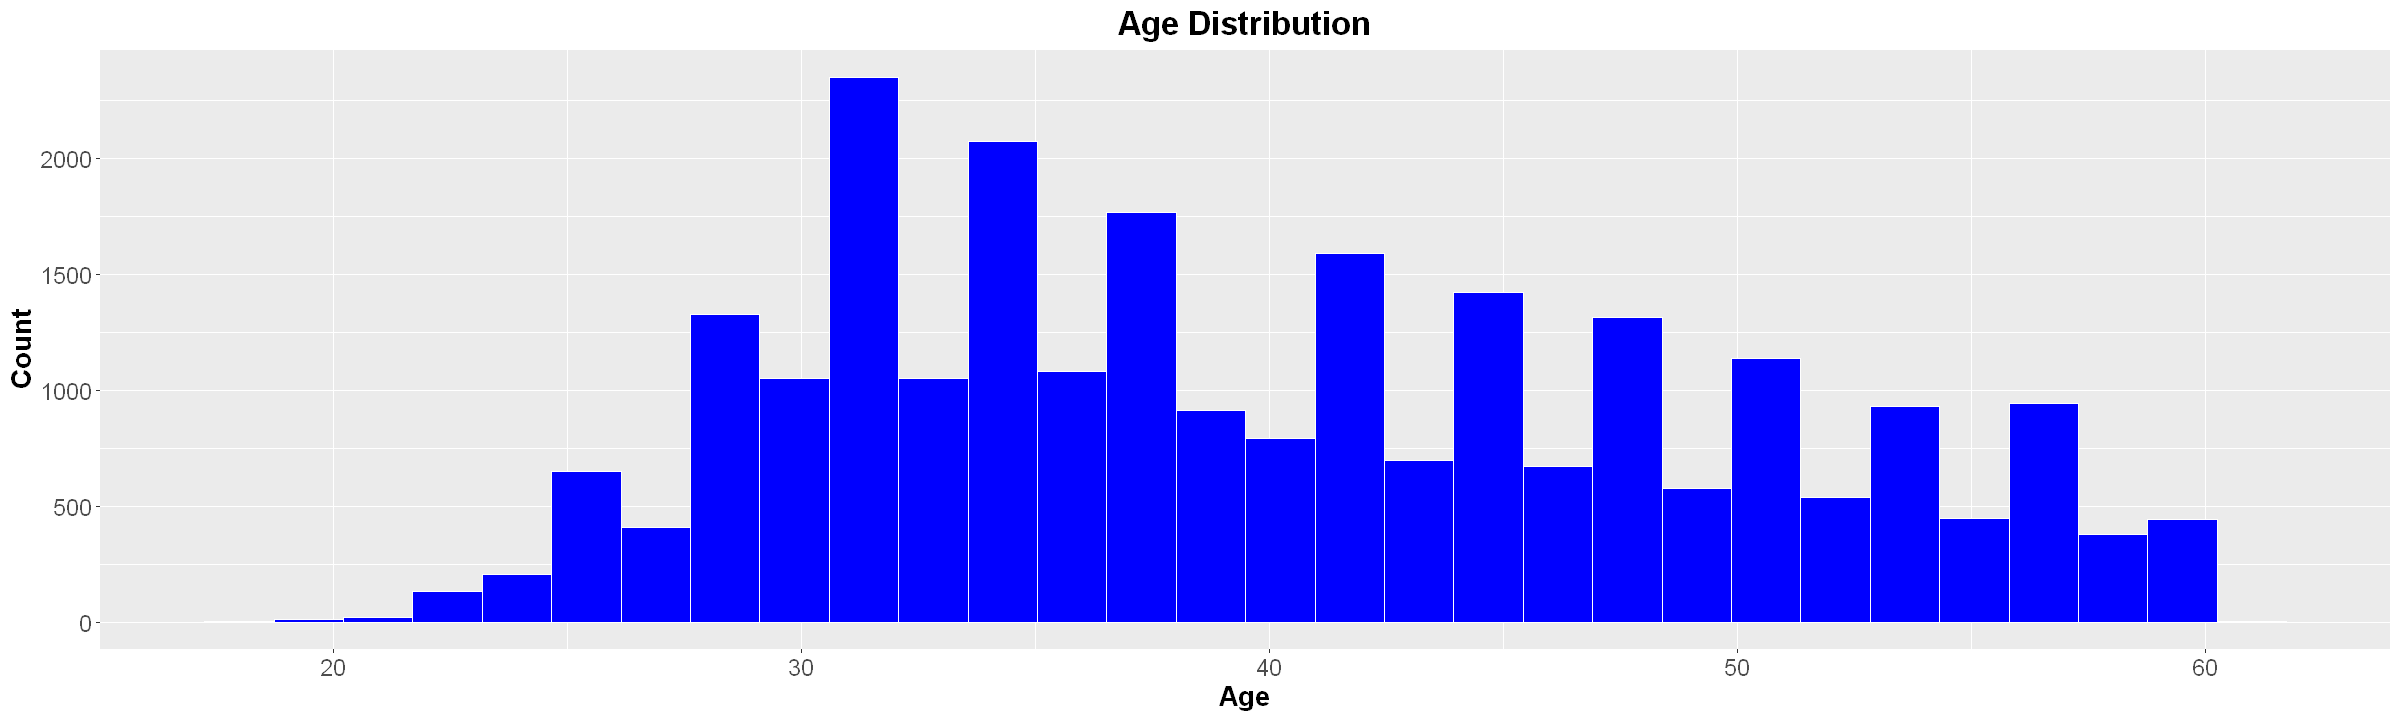

In [14]:
# Width and Height
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = age)) +
  geom_histogram(bins = 30, fill = "blue", color = "white") +
  labs(title = "Age Distribution", x = "Age", y = "Count") +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Most clients are aged 30–35, indicating strong engagement from younger working adults.
- The distribution is right-skewed, with fewer older clients (50+), suggesting lower outreach or interest in that segment.
- Under-20s are rare, highlighting a gap in youth targeting.
- These trends shows marketing segmentation and product design needs tailoring offers to high-response age groups and exploring strategies for underserved ones.

**Distribution of Campaign Contacts (Numeric)**

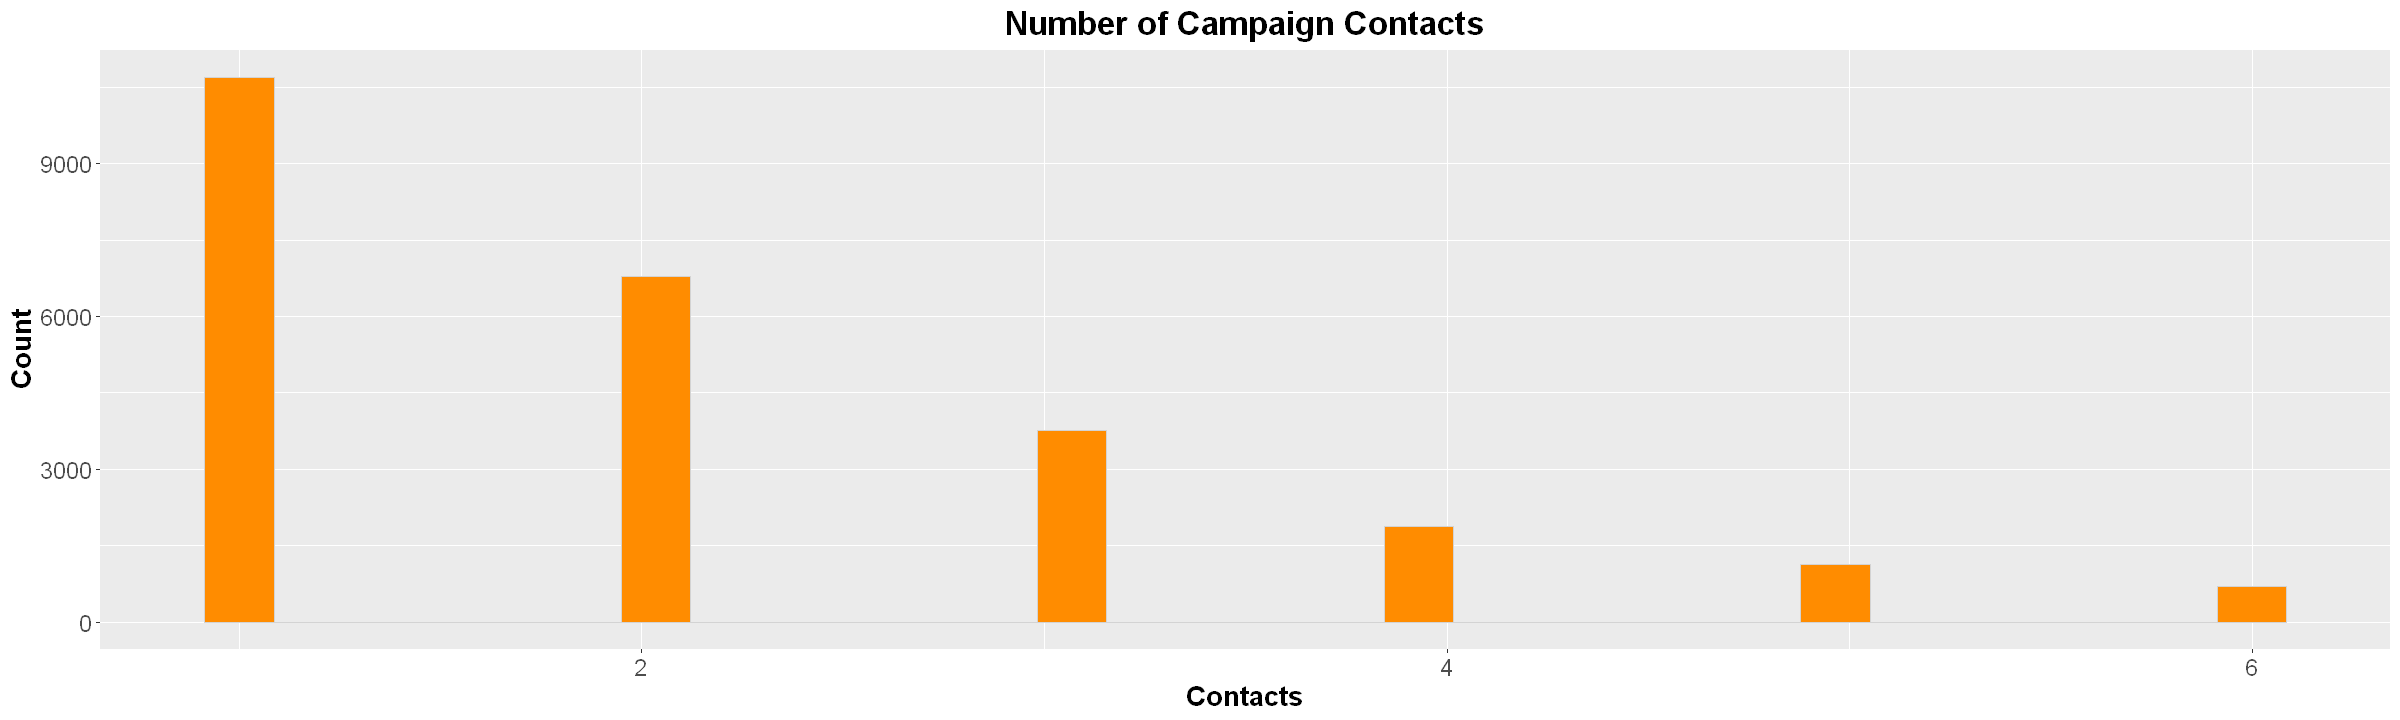

In [15]:
# Width and Height
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = num_contacts)) +
  geom_histogram(bins = 30, fill = "darkorange", color = "lightgray") +
  labs(title = "Number of Campaign Contacts", x = "Contacts", y = "Count") +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Most clients were contacted only once, indicating a single-touch strategy dominates.
- Contact frequency drops sharply after the first attempt, suggesting limited follow-up.
- Low multi-contact engagement may affect conversion rates, repeated contact could improve outcomes.
- Distribution is right-skewed, showing diminishing returns or reduced effort beyond initial outreach.

**Job Type Frequency**

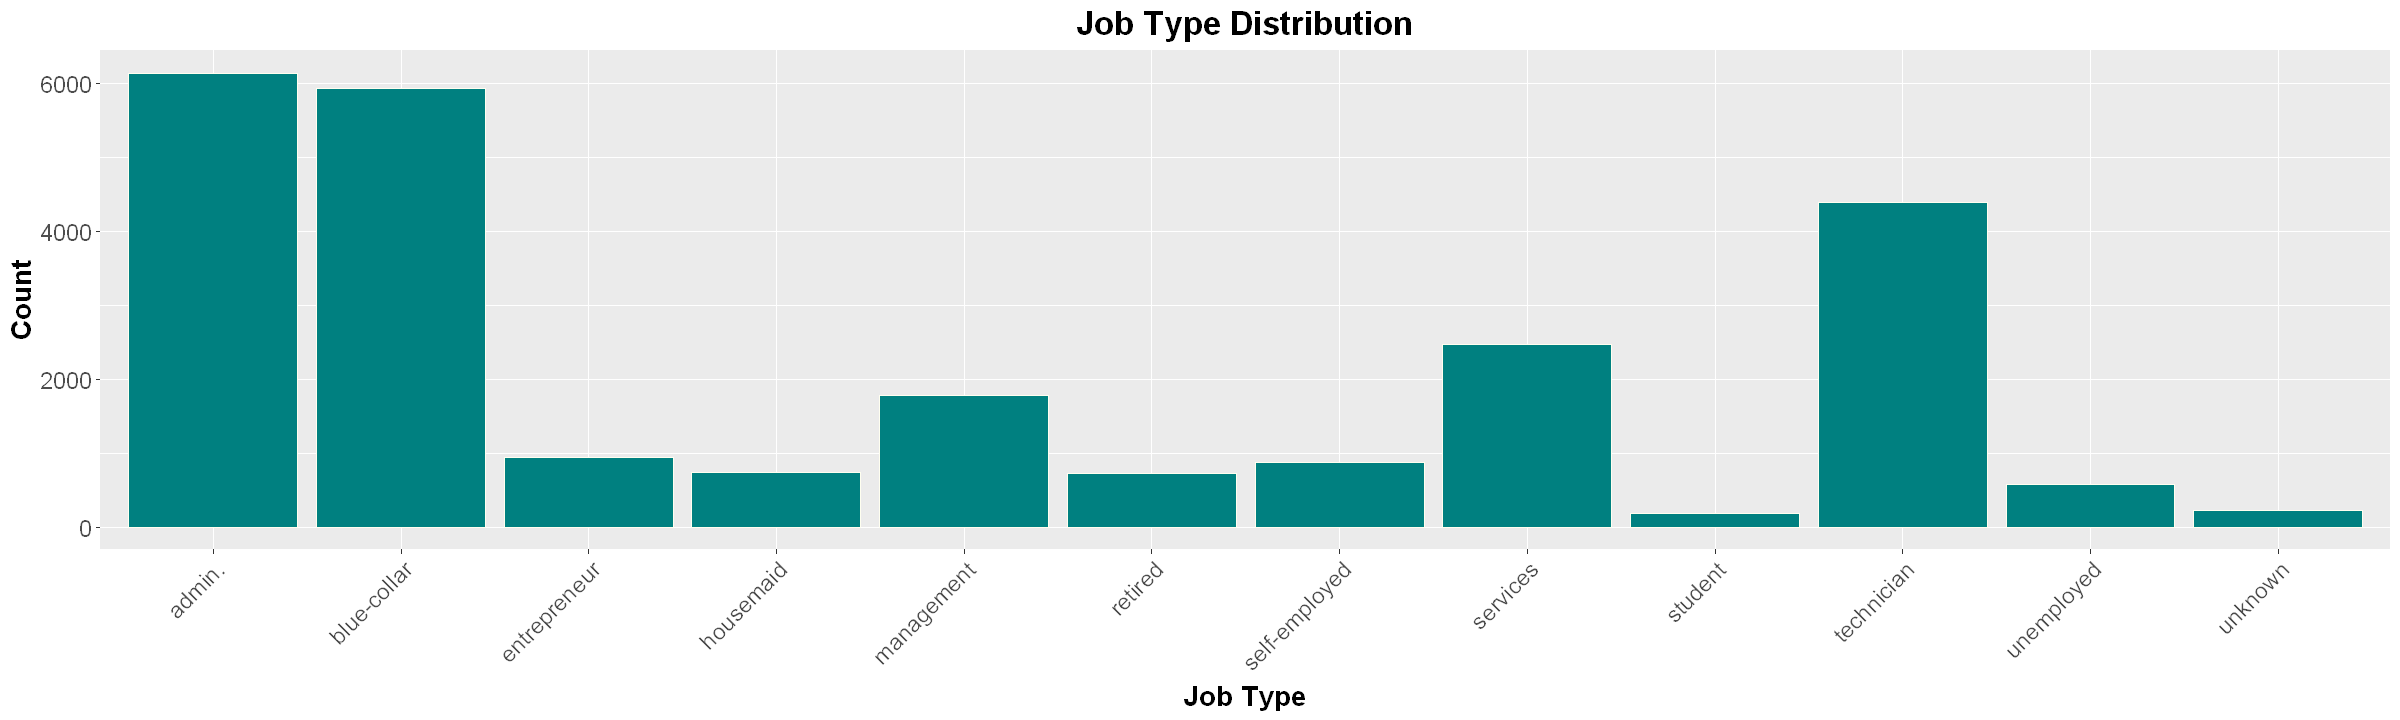

In [16]:
options(repr.plot.width = 20, repr.plot.height = 6)
# color teal and ivory
ggplot(data, aes(x = job)) +
  geom_bar(fill = "#008080", color="#FFFFF0") + 
  labs(title = "Job Type Distribution", x = "Job Type", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Blue-collar and admin roles dominate, indicating strong representation from manual labor and leadership segments.
- Technicians and service workers also form a significant portion of the client base.
- Students, housemaids, and unknown job types are underrepresented, suggesting limited outreach or engagement in these groups.
- Diverse job categories imply the campaign reaches a broad employment spectrum, useful for tailoring offers by profession.

**Marital Status Frequency**

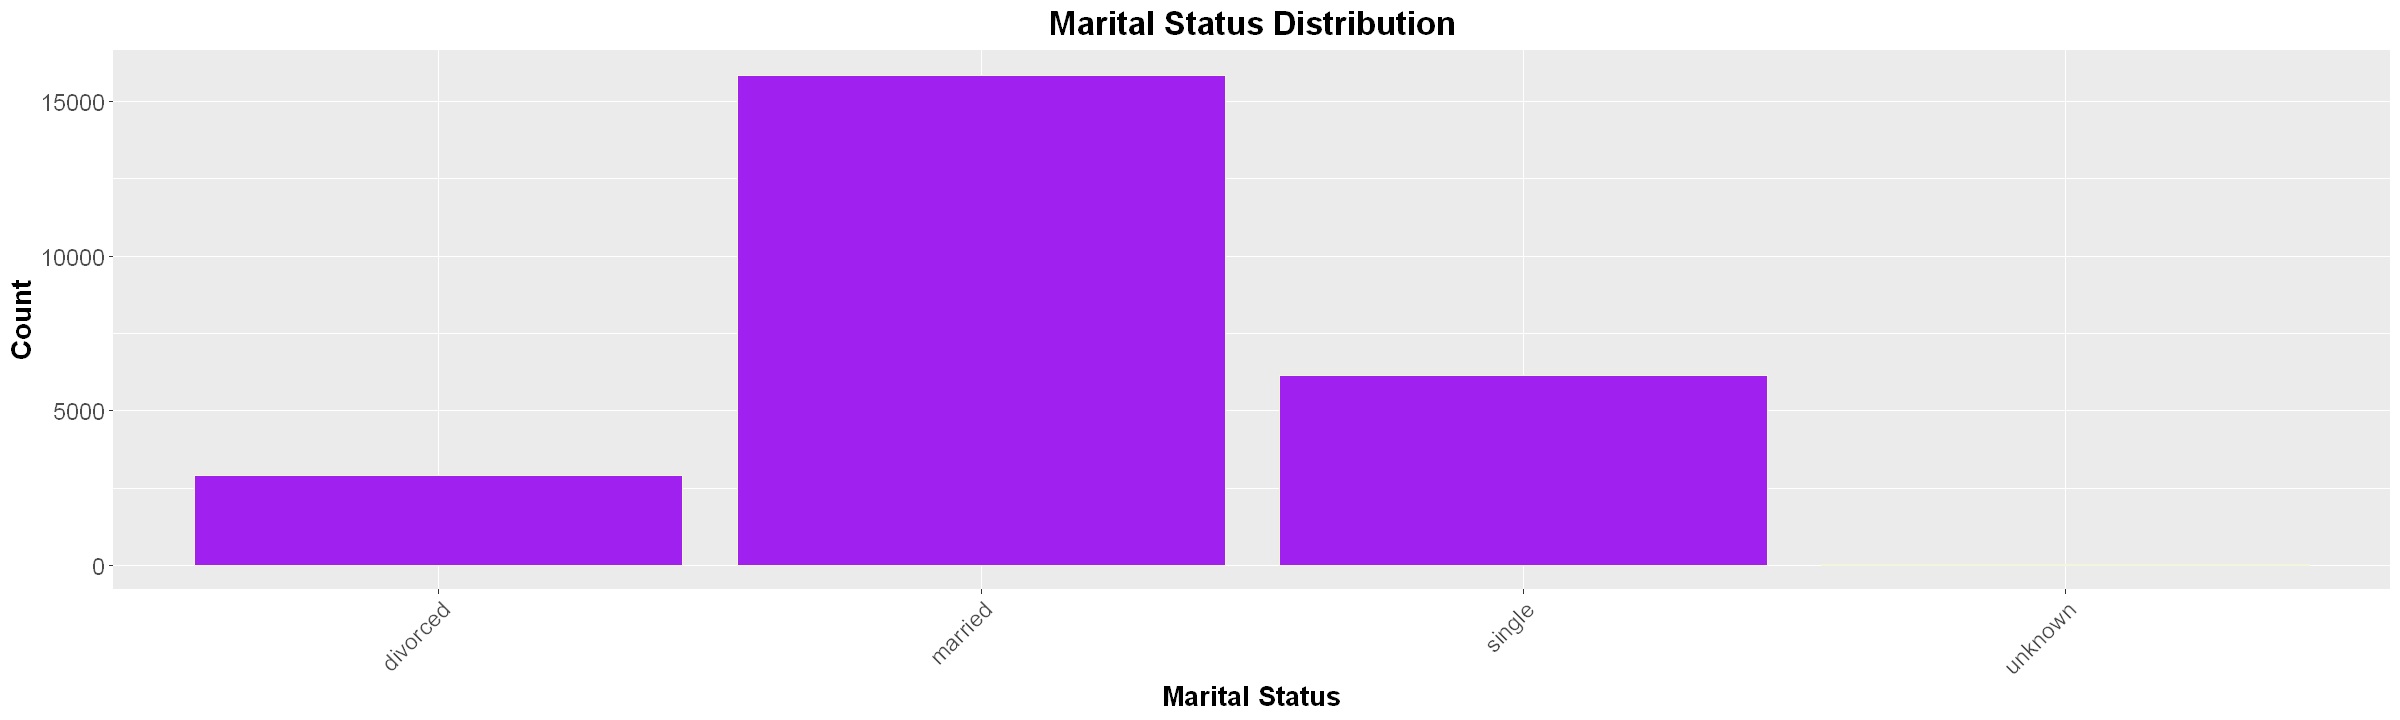

In [17]:
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = marital_status)) +
  geom_bar(fill = "purple", color="beige") +
  labs(title = "Marital Status Distribution", x = "Marital Status", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Married clients dominate, indicating strong engagement from this demographic.
- Single individuals form the second-largest group, suggesting potential for targeted campaigns.
- Divorced clients are less represented, possibly due to lower outreach or interest.
- The distribution reflects life-stage diversity, which can inform personalized marketing strategies.

**Education Level Frequency**

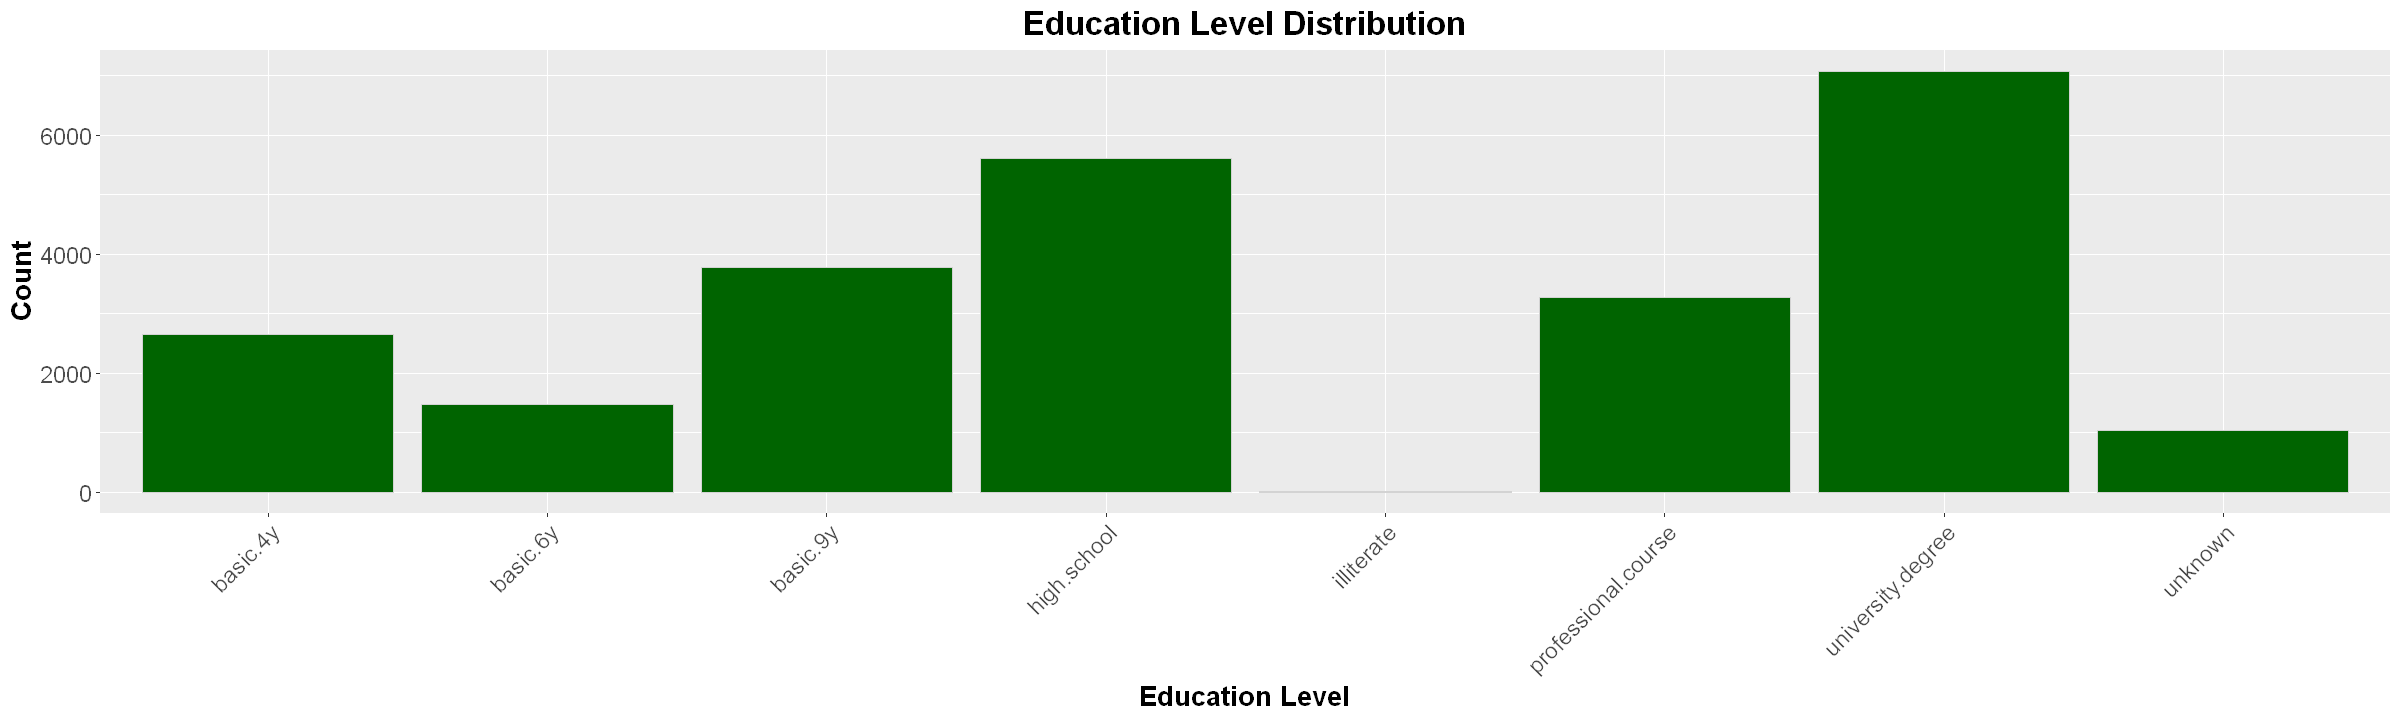

In [18]:
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = education_level)) +
  geom_bar(fill = "darkgreen", color = "lightgray") +
  labs(title = "Education Level Distribution", x = "Education Level", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- University graduates form the largest group, indicating high educational attainment among clients.
- High school and basic.9y levels also show strong representation, suggesting a mix of mid-level education.
- Illiterate individuals are very few, pointing to limited engagement from low-literacy segments.
- The distribution supports education-based targeting, with potential to tailor financial products or messaging by qualification level.

**Credit Default Status**

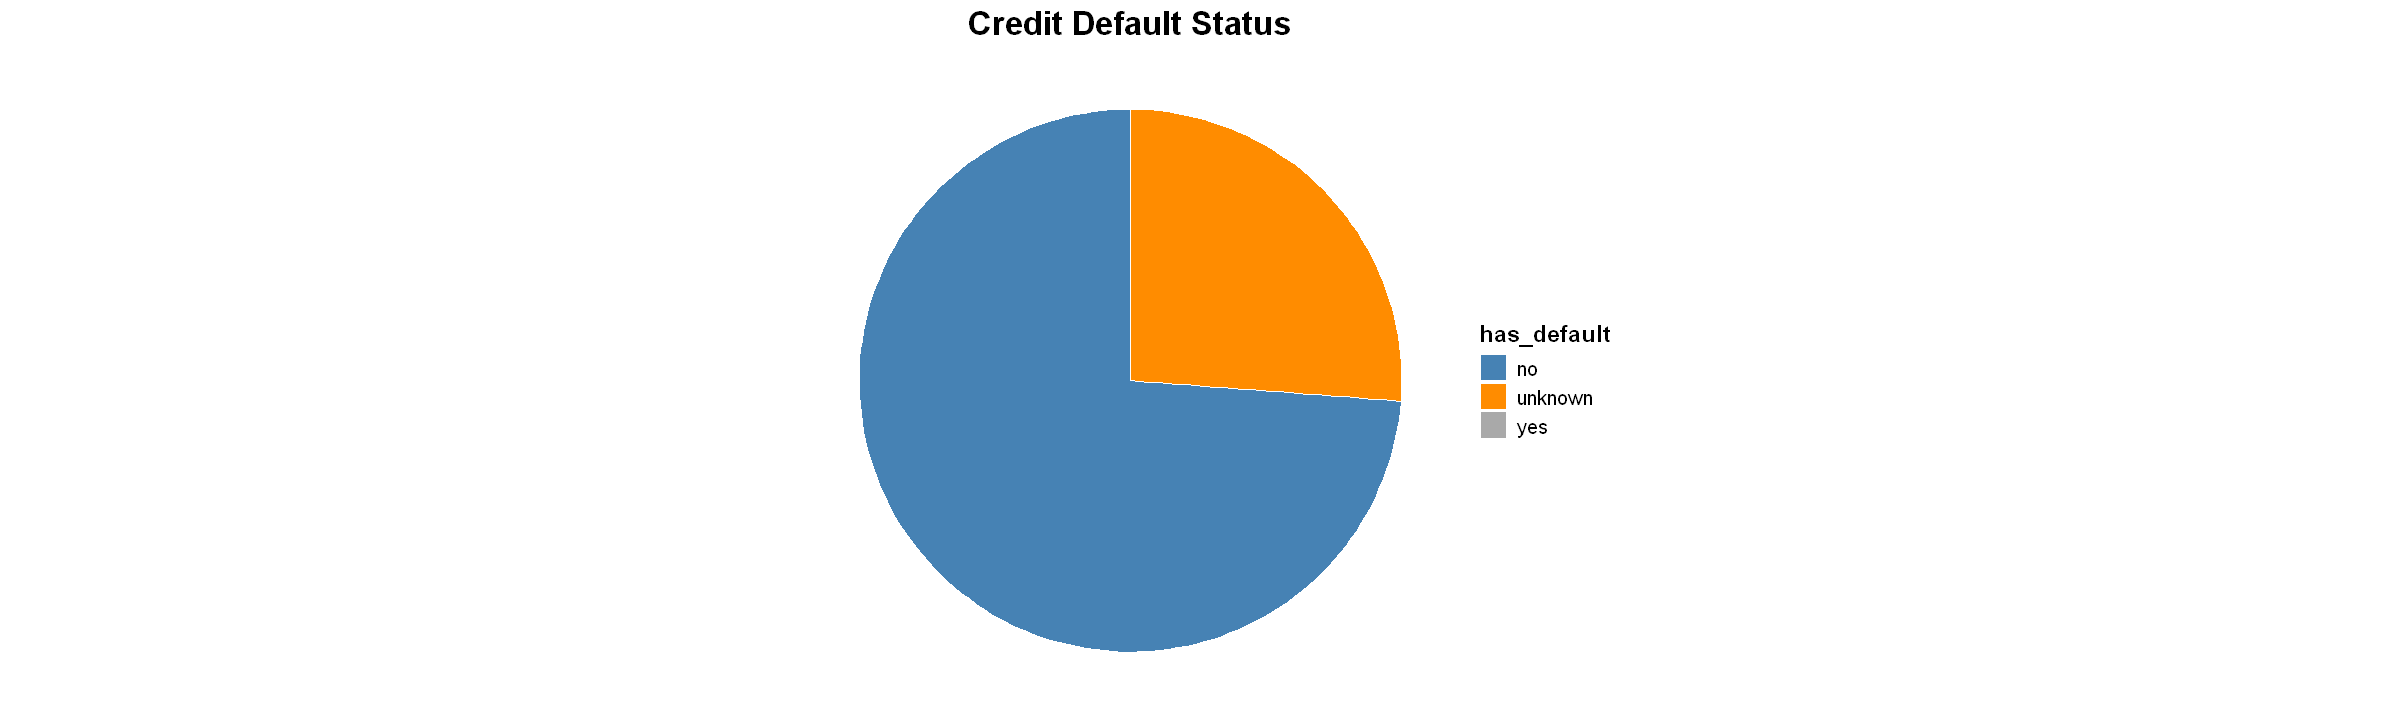

In [19]:
options(repr.plot.width = 20, repr.plot.height = 6)

# Preparing data with percentage labels
default_freq <- data %>%
  count(has_default) %>%
  mutate(percent = round(n / sum(n) * 100, 1),
         label = paste0(has_default, "\n", percent, "%"))

ggplot(default_freq, aes(x = "", y = n, fill = has_default)) +
  geom_bar(stat = "identity", width = 1, color = "white") +
  coord_polar("y") +
  labs(title = "Credit Default Status") +
  theme_void() +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    legend.title = element_text(size = 14, face = "bold"),
    legend.text = element_text(size = 12)
  ) +
  scale_fill_manual(values = c("#4682B4", "#FF8C00", "#A9A9A9"))

- The majority of clients have no credit default, indicating a generally low-risk population.
- A notable portion is labeled unknown, which may affect risk modeling.
- Very few clients have defaulted, suggesting minimal exposure to credit risk but also a potential blind spot if defaults are underreported.
- The distribution supports confidence in client's financial stability.

**Housing Loan Status**

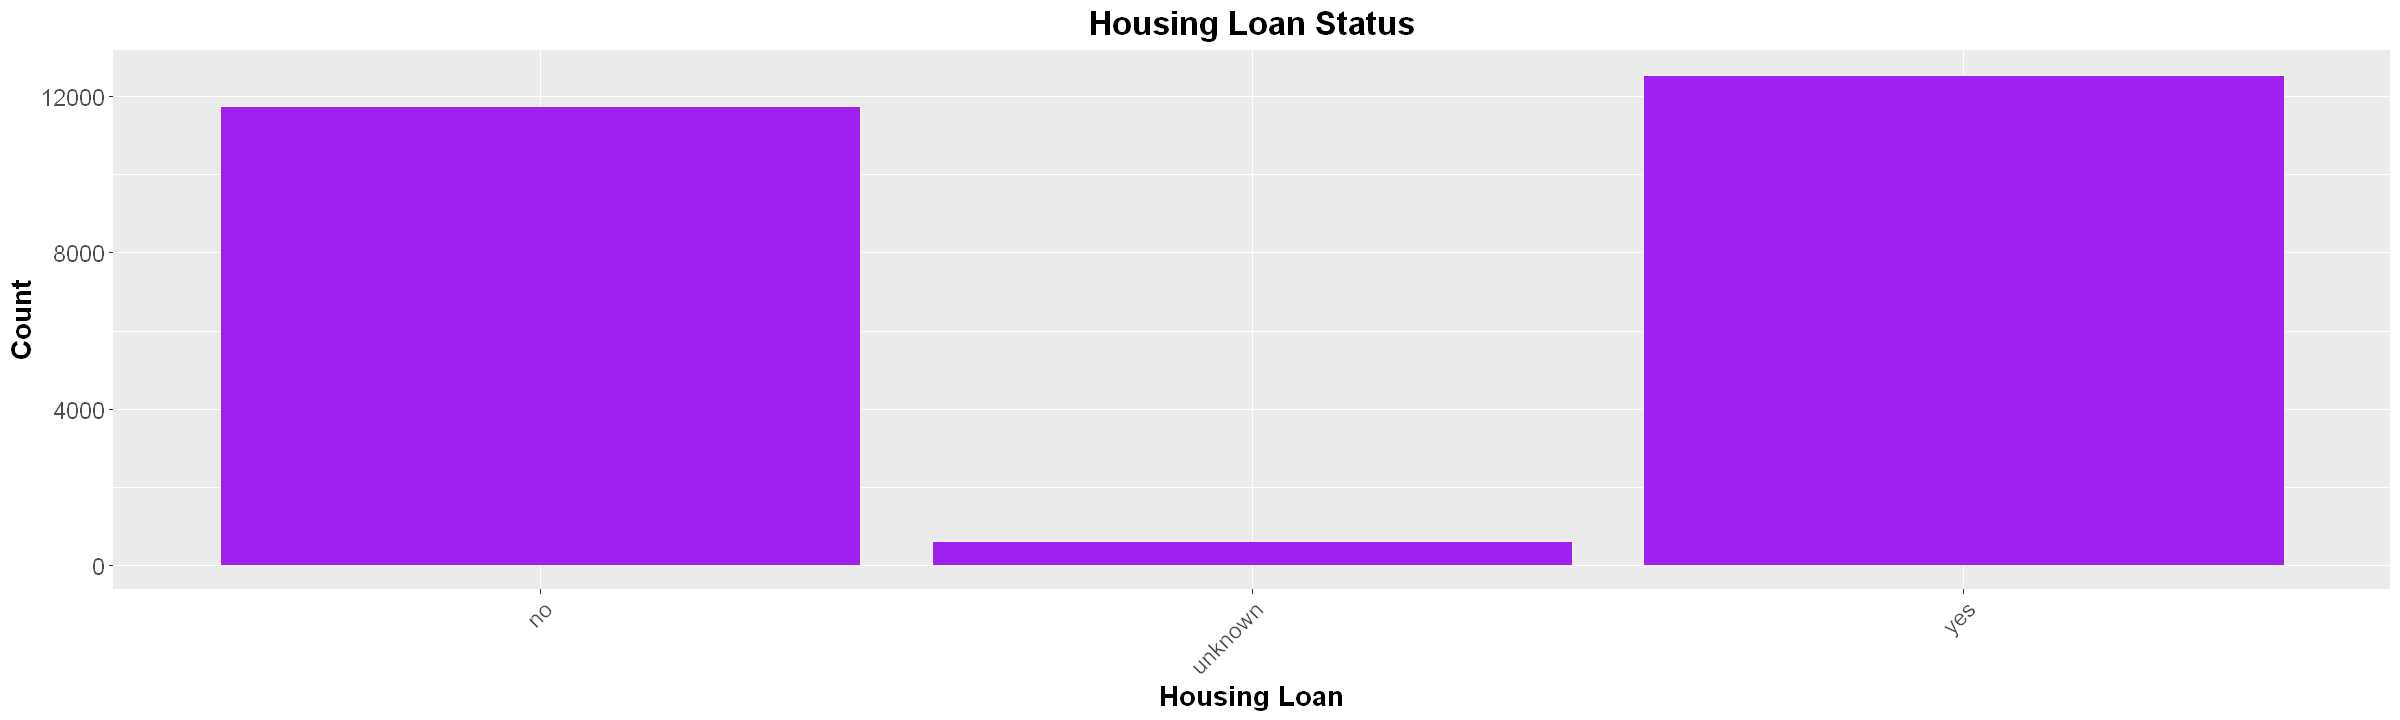

In [20]:
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = has_housing_loan)) +
  geom_bar(fill = "purple", color="beige") +
  labs(title = "Housing Loan Status", x = "Housing Loan", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Clients with and without housing loans are nearly equal, suggesting balanced representation of both groups.
- A small portion is labeled unknown, which may affect modeling accuracy.
- The even split indicates that housing loan status alone may not be a strong differentiator.

**Euribor Rate Trend**

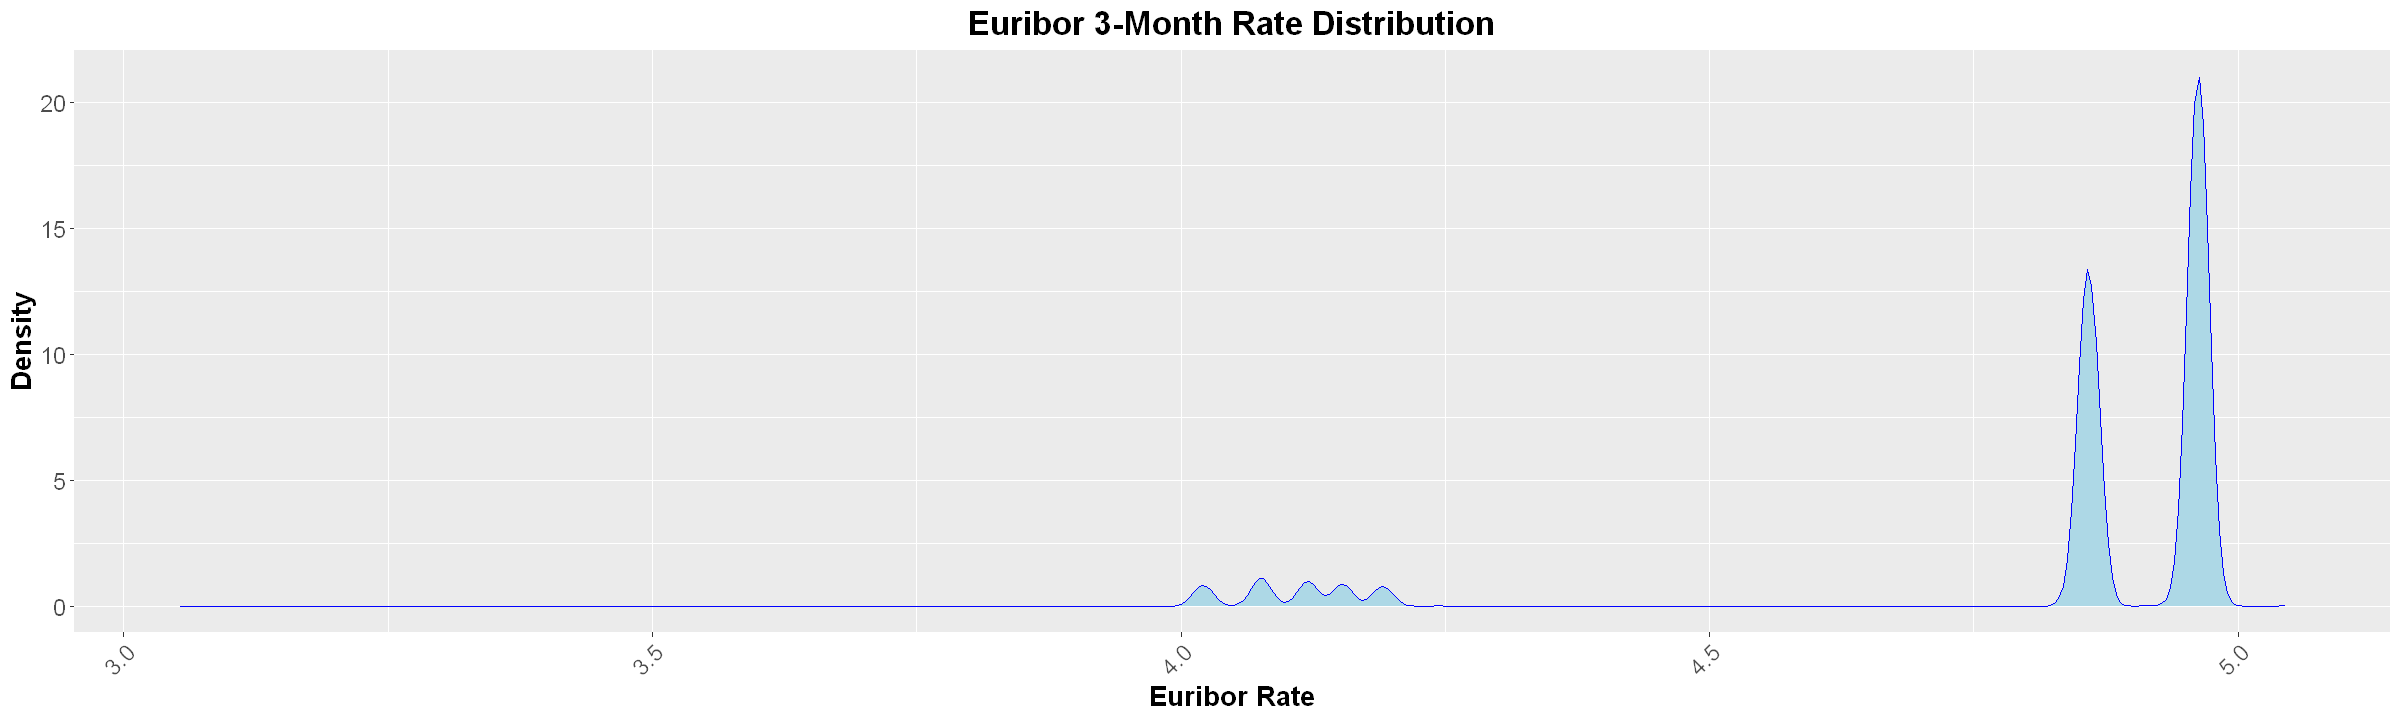

In [21]:
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = euribor_rate)) +
  geom_density(color = "blue", fill = "lightblue") +
  labs(title = "Euribor 3-Month Rate Distribution", x = "Euribor Rate", y = "Density") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Two distinct peaks suggest the Euribor rate clustered around specific values during the observed period.
- Higher density on the right side indicates more frequent occurrence of elevated interest rates.
- Lower density on the left implies fewer instances of low Euribor rates.
- The bimodal pattern may reflect shifts in monetary policy or economic cycles.
- Useful for assessing interest rate exposure and timing of client engagements in financial modeling.

### Bivariate Analysis

**Age vs Subscription Outcome**

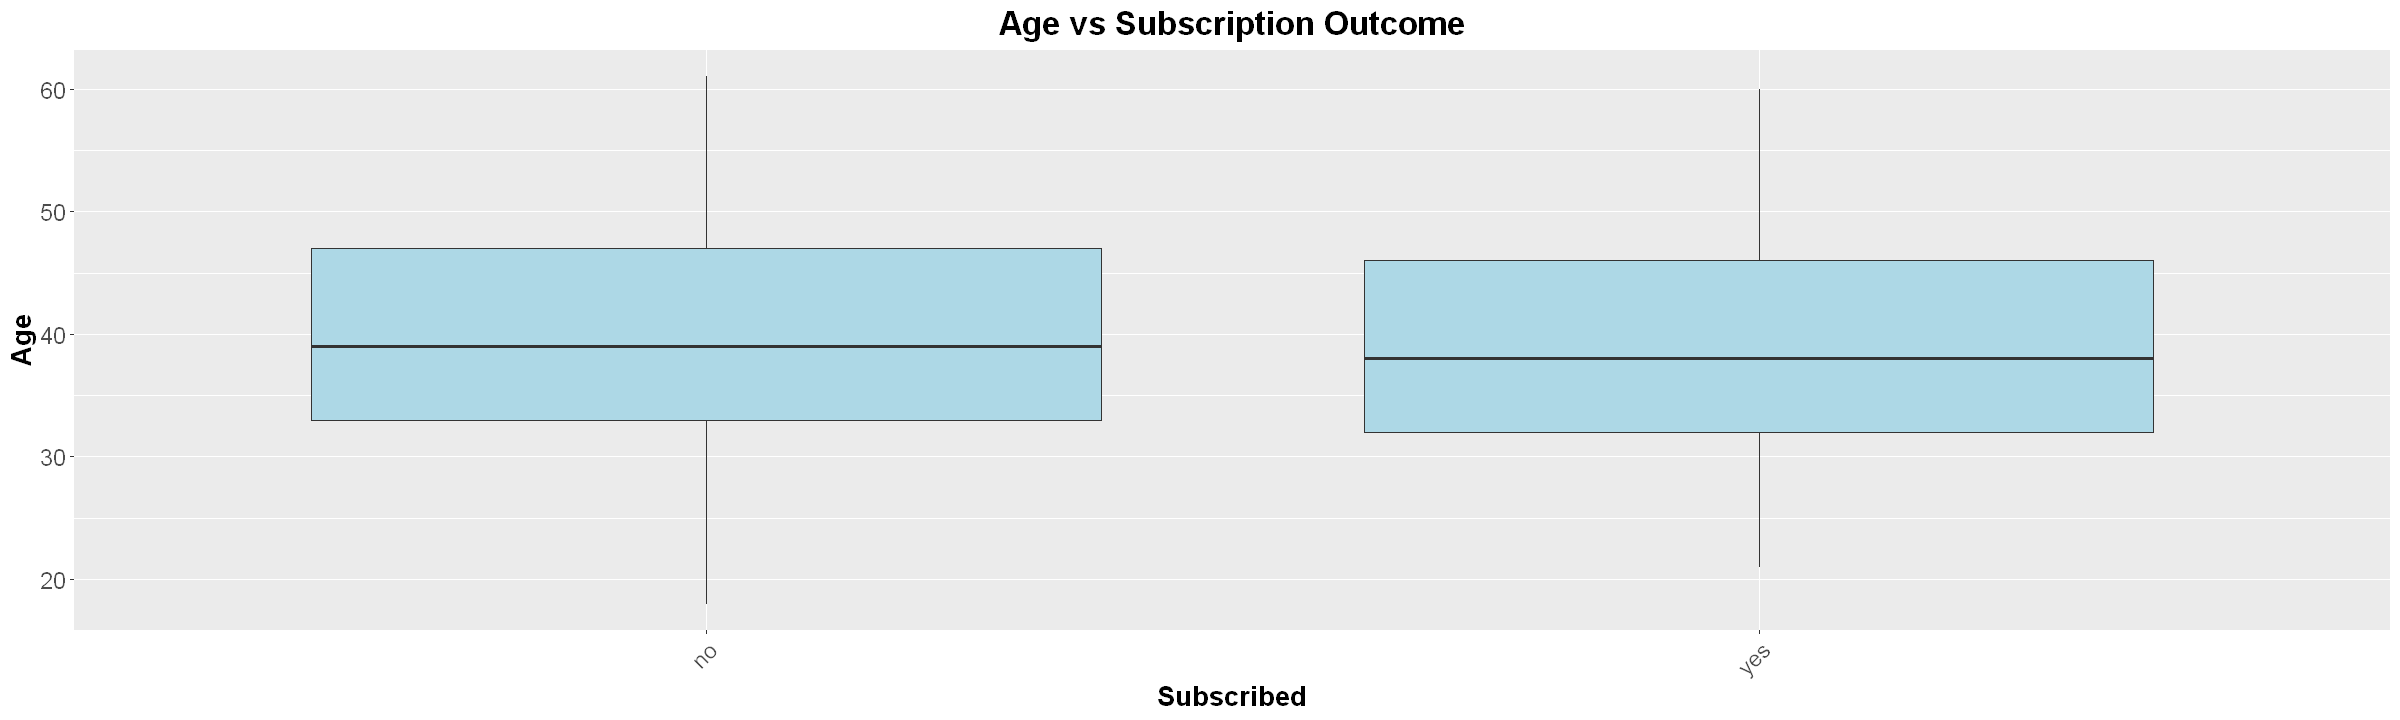

In [22]:
# Boxplot
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = y, y = age)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Age vs Subscription Outcome", x = "Subscribed", y = "Age") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Median age is similar for both subscribed and non-subscribed groups, suggesting age alone may not strongly influence subscription.
- Age spread is wider among non-subscribers, indicating more variability in that group.

**Job Type vs Subscription Outcome**

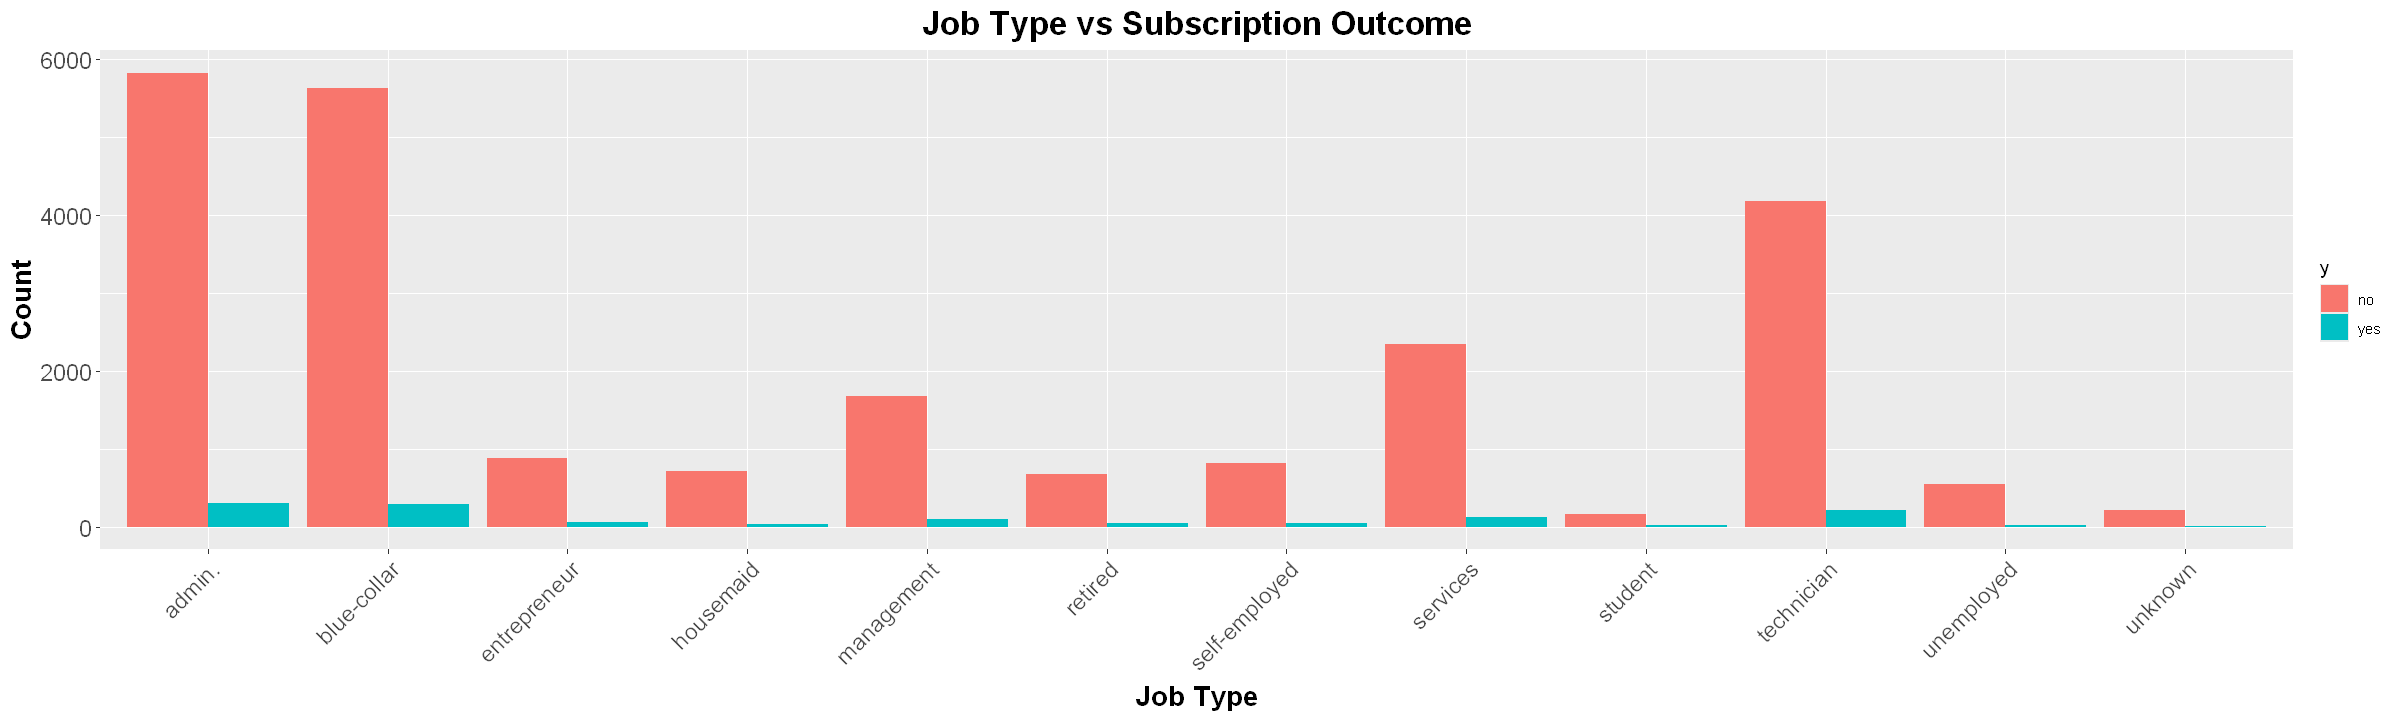

In [23]:
# Grouped bar chart
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = job, fill = y)) +
  geom_bar(position = "dodge") +
  labs(title = "Job Type vs Subscription Outcome", x = "Job Type", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Most job types show higher no counts, indicating low overall subscription rates across occupations.
- Blue-collar and management roles dominate in volume**, but have low-to-high subscription conversion.
- Retired and unemployed groups show the lowest subscription interest, possibly due to financial caution or availability.

**Education Level vs Subscription Outcome**

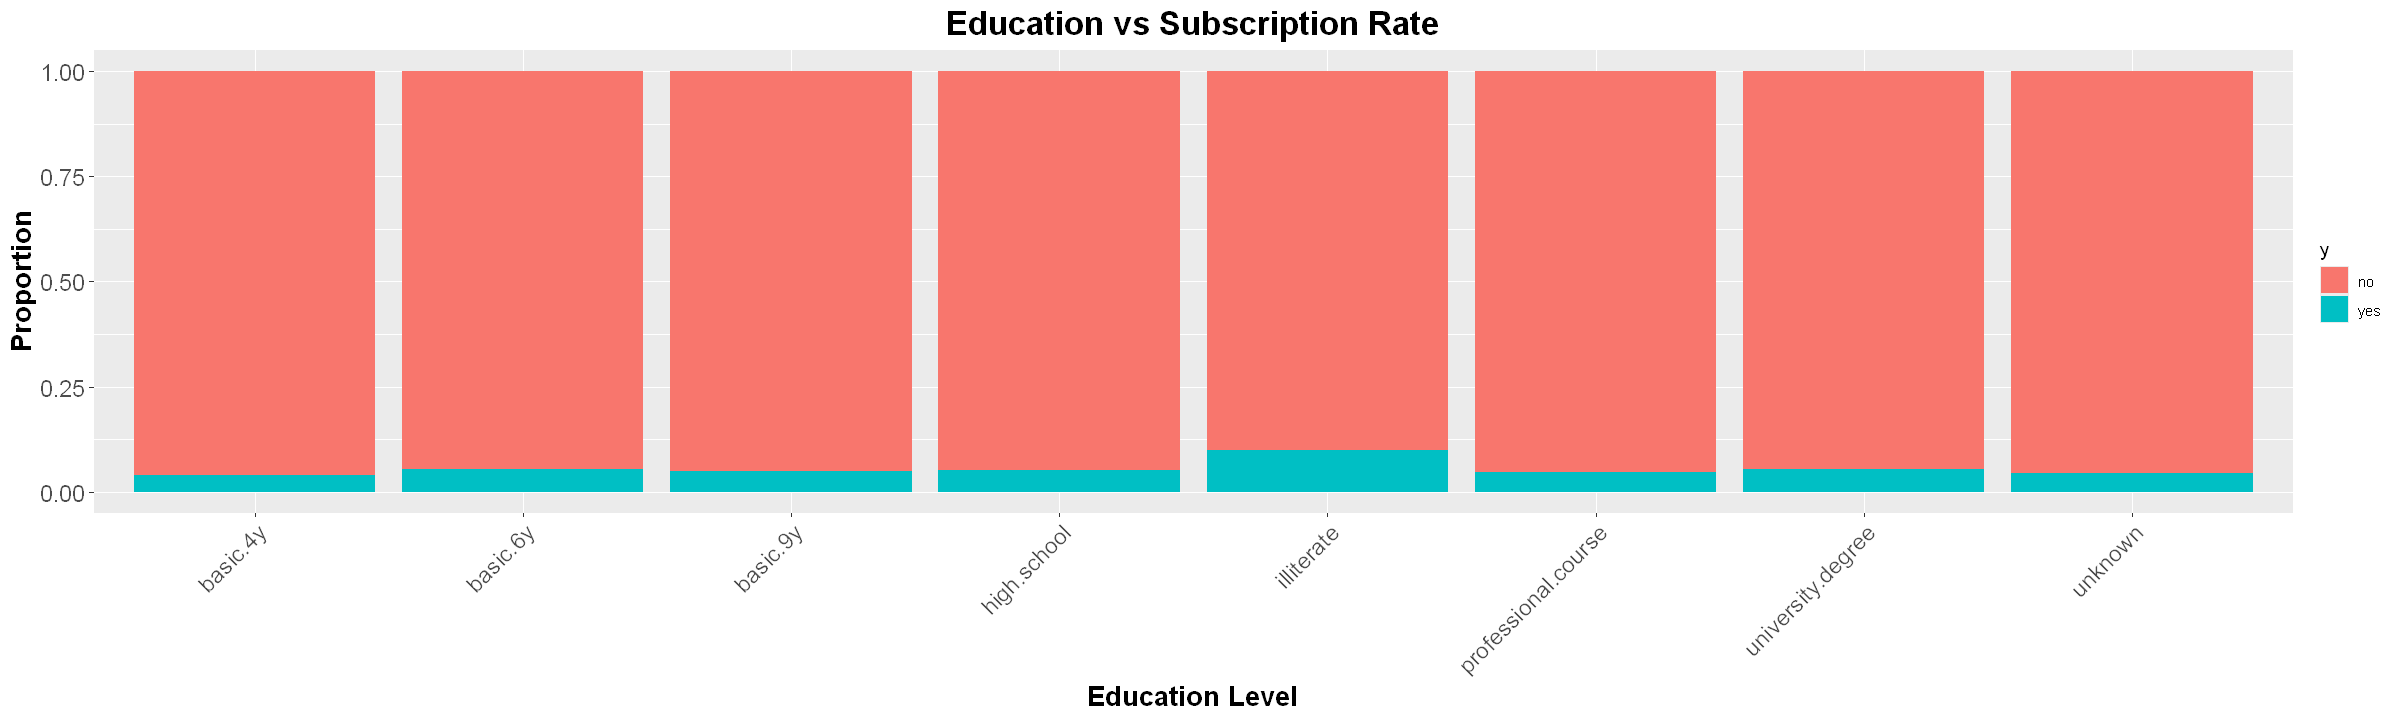

In [24]:
# Stacked bar chart
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = education_level, fill = y)) +
  geom_bar(position = "fill") +
  labs(title = "Education vs Subscription Rate", x = "Education Level", y = "Proportion") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Most education levels show low subscription proportions, with no outcomes dominating across the board.
- Illiterate individuals have a relatively higher subscription rate, which may reflect targeted outreach.
- University graduates and high school leavers show moderate subscription interest, but still lean heavily toward no.
- Unknown education levels have mixed outcomes.

**Marital Status vs Subscription Outcome**

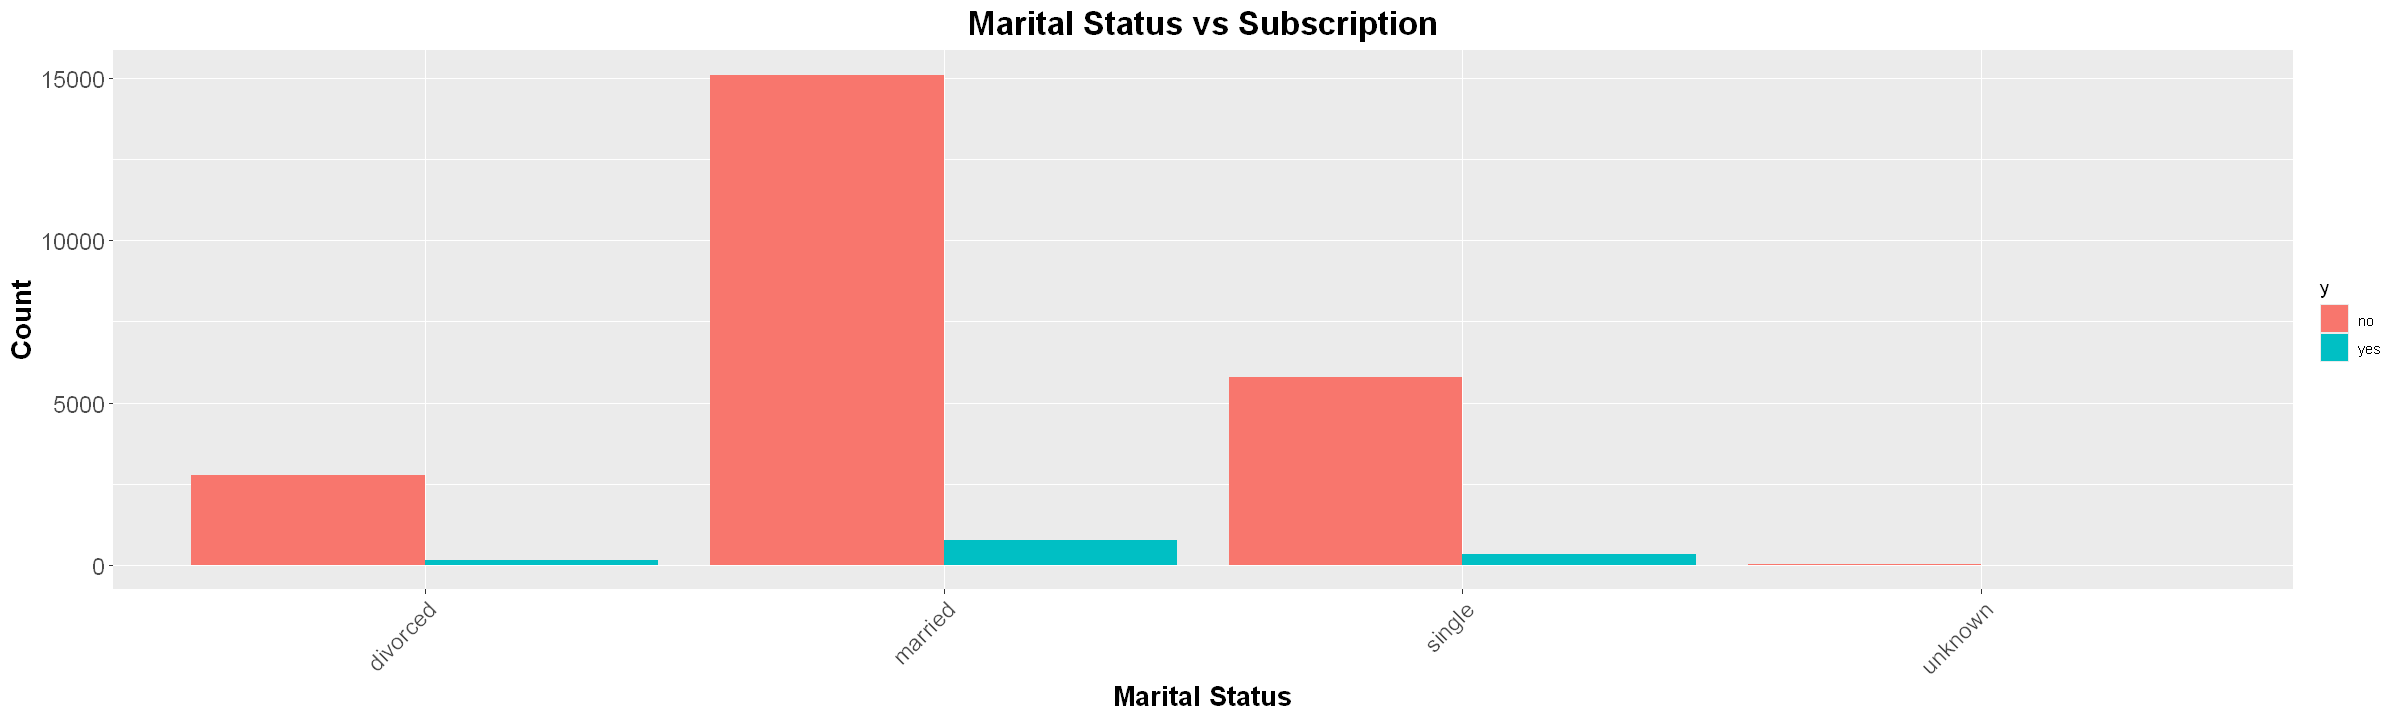

In [25]:
# Grouped bar chart
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = marital_status, fill = y)) +
  geom_bar(position = "dodge") +
  labs(title = "Marital Status vs Subscription", x = "Marital Status", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),  
    axis.title.x = element_text(size = 16, face = "bold"),             
    axis.title.y = element_text(size = 16, face = "bold"),             
    axis.text.x  = element_text(size = 14),                            
    axis.text.y  = element_text(size = 14)                            
  )

- Married individuals dominate the dataset, but have a low subscription rate relative to their count.
- Single clients show a moderate proportion of subscriptions compared to married or divorced groups.
- Divorced individuals have low subscription interest, though still fewer than singles.
- Unknown marital status has minimal impact, with very low counts in both categories.

**Housing Loan vs Subscription Outcome**

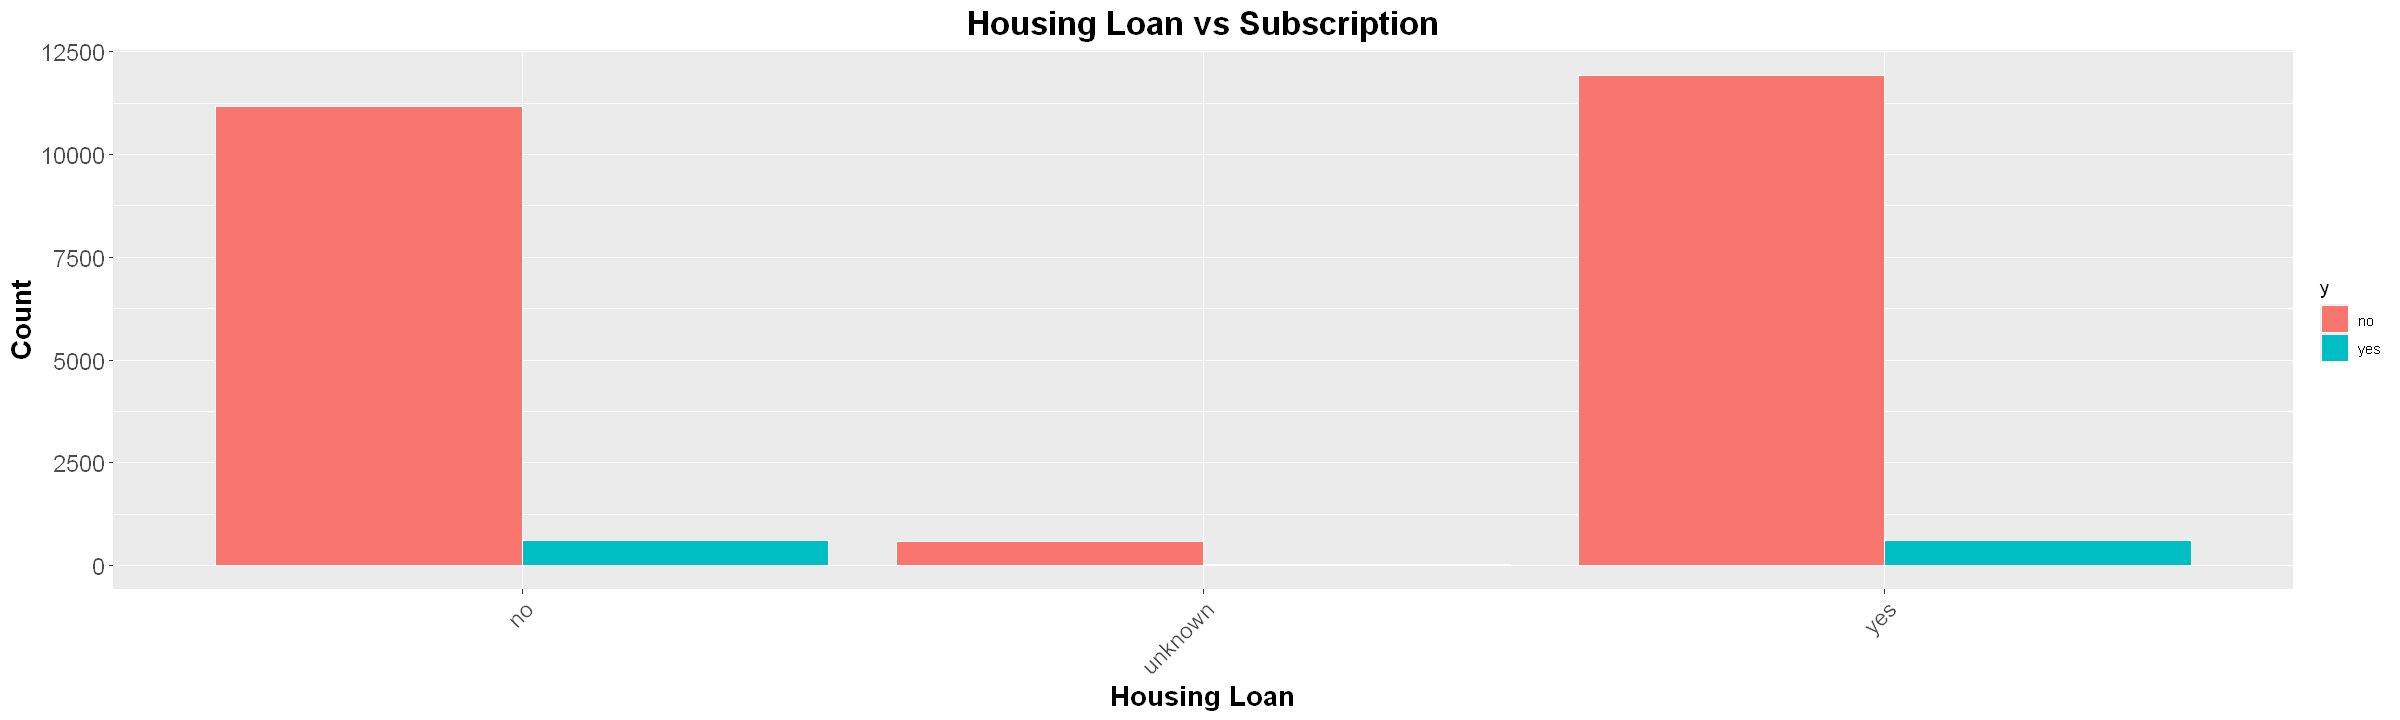

In [26]:
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = has_housing_loan, fill = y)) +
  geom_bar(position = "dodge", color = "white") +
  labs(title = "Housing Loan vs Subscription", x = "Housing Loan", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14),
    axis.text.y  = element_text(size = 14)
  )

- Non-subscription dominates across all housing loan categories.
- Subscription rates are low regardless of housing loan status, suggesting loan presence alone doesn't drive engagement.
- Unknown loan status group is small, but still follows the same pattern of low subscription.

**Month of Contact vs Subscription Outcome**

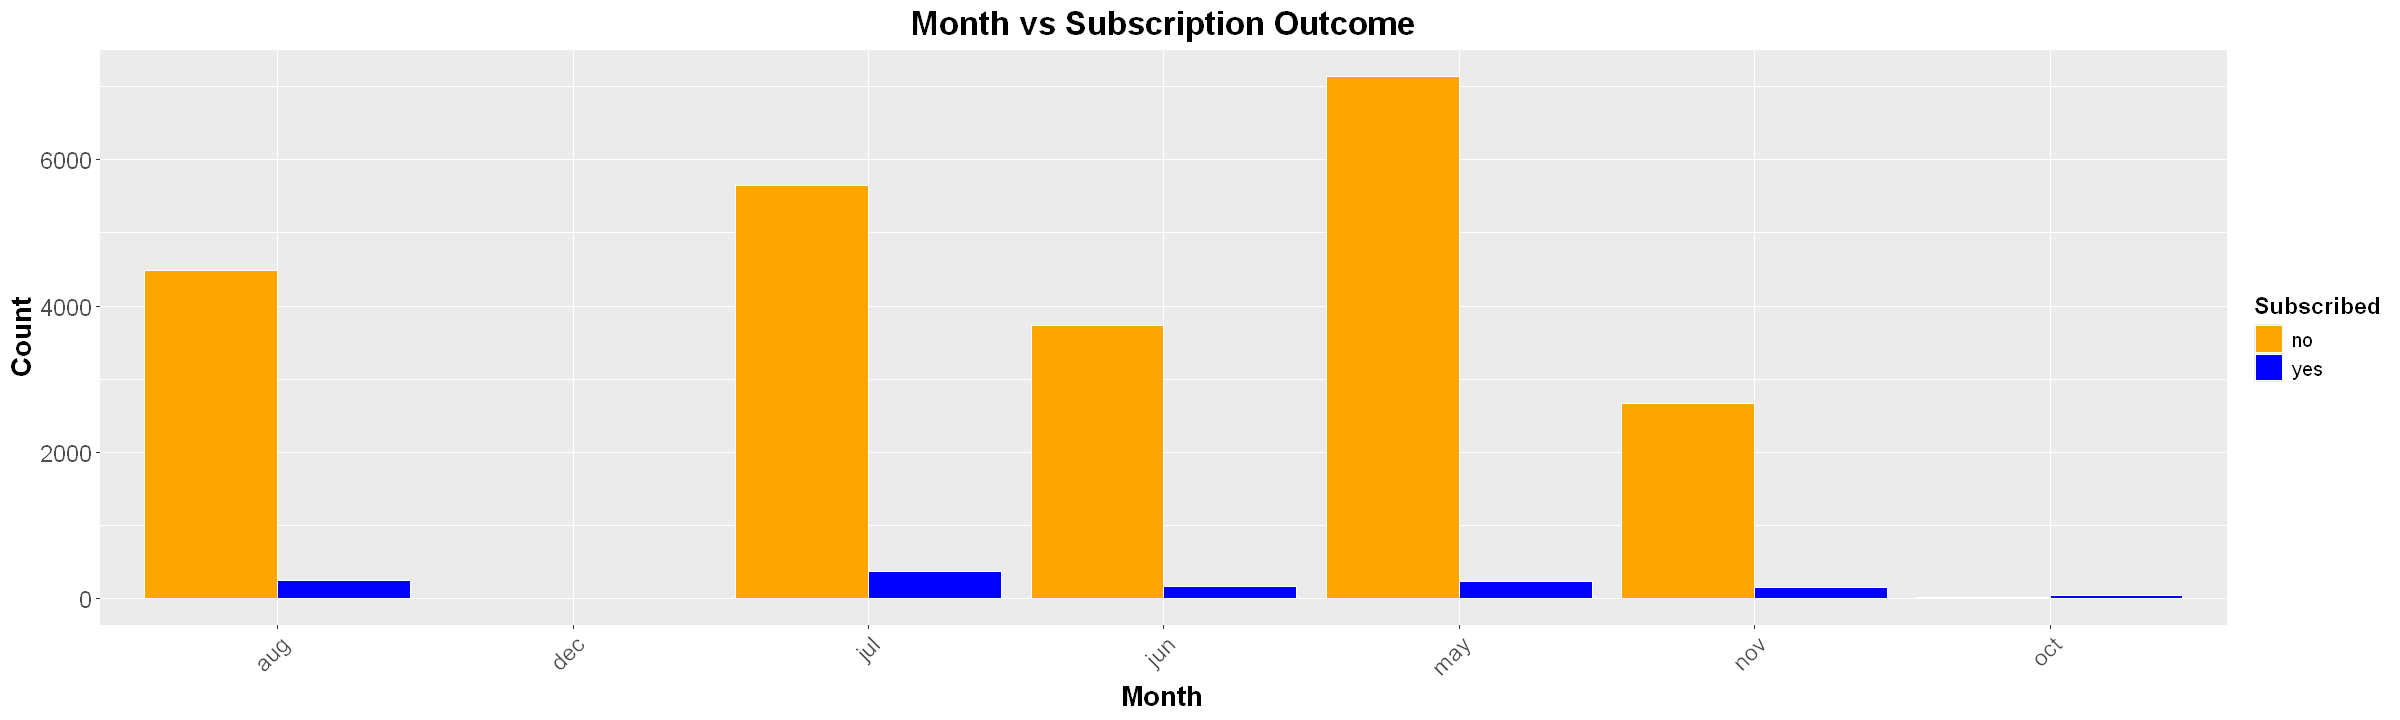

In [27]:
options(repr.plot.width = 20, repr.plot.height = 6)

month_summary <- data %>%
  count(month_of_contact, y)

ggplot(month_summary, aes(x = month_of_contact, y = n, fill = y)) +
  geom_bar(stat = "identity", position = "dodge", color = "white") +
  labs(title = "Month vs Subscription Outcome", x = "Month", y = "Count", fill = "Subscribed") +
  scale_fill_manual(values = c("no" = "orange", "yes" = "blue")) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- November, July, and May had the highest overall contact volumes, but also the highest number of non-subscriptions.
- Subscription rates are consistently low across all months.
- Subscription is high on July while moderate on May and November.

**Previous Campaign Outcome vs Subscription**

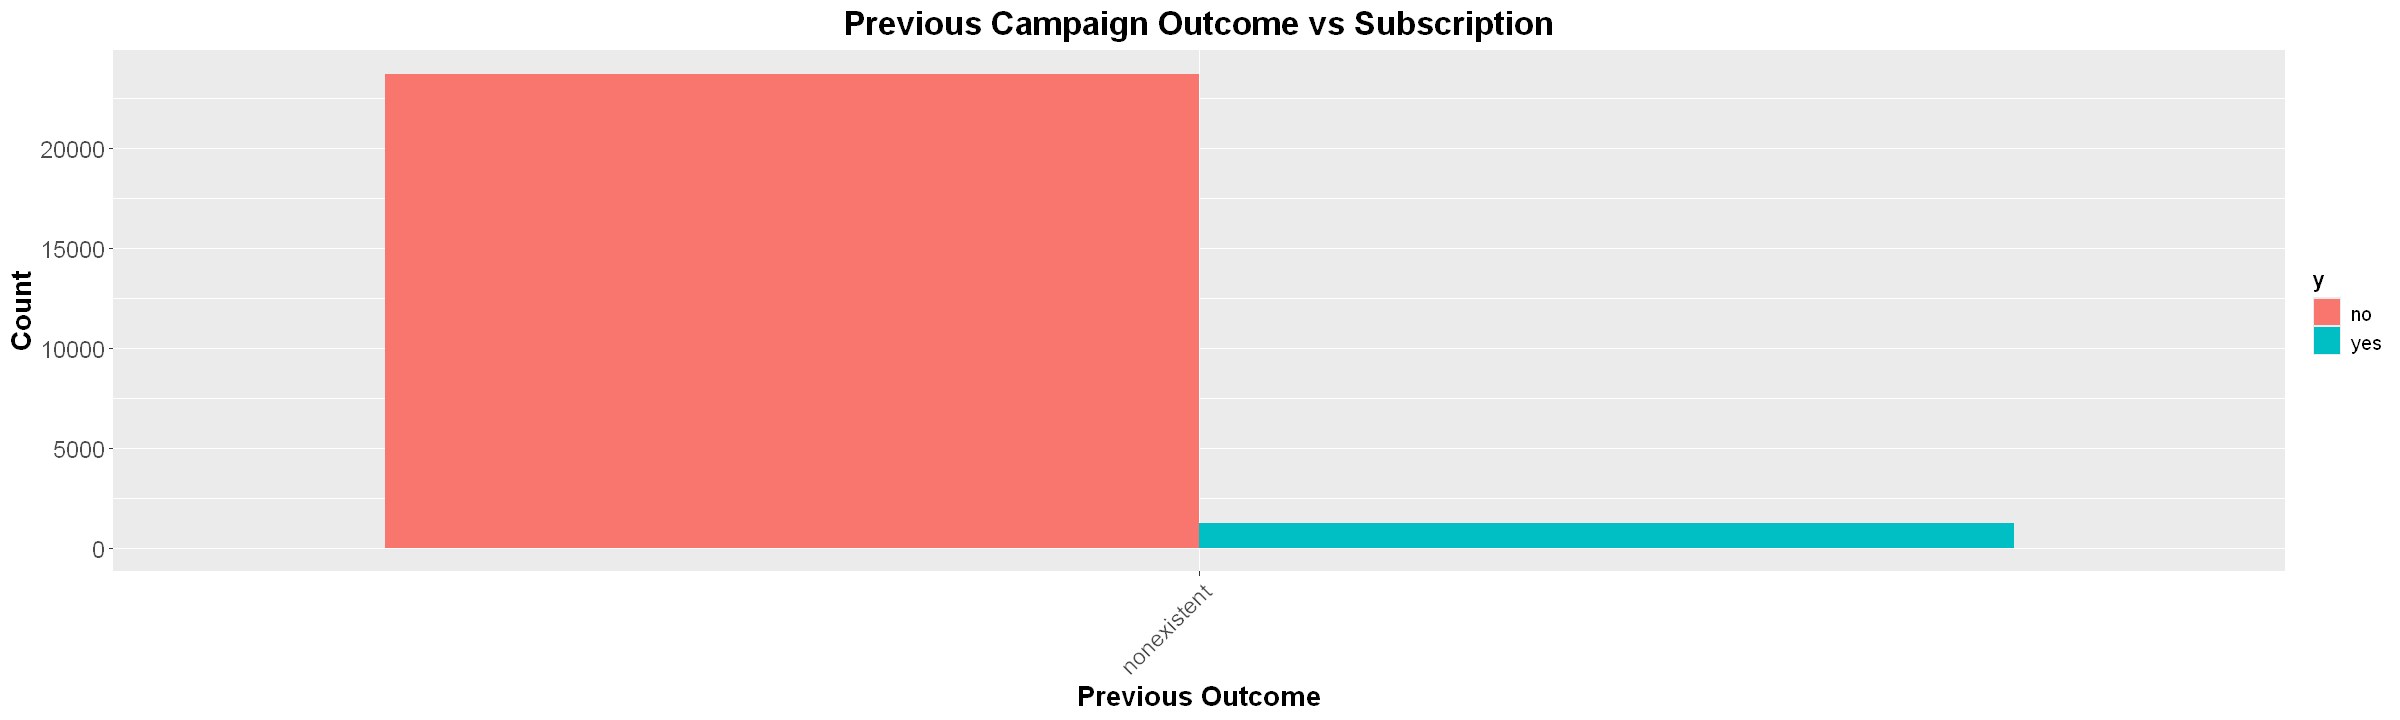

In [28]:
# Grouped Bar Chart
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = prev_campaign_outcome, fill = y)) +
  geom_bar(position = "dodge") +
  labs(title = "Previous Campaign Outcome vs Subscription", x = "Previous Outcome", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Most clients had a failed previous campaign, and the majority of them did not subscribe again.
- Clients with a successful previous campaign are more likely to subscribe, suggesting positive campaign history boosts engagement.
- Campaign history is a strong behavioral signal, success builds trust and increases conversion likelihood.

**Number of Contacts vs Subscription**

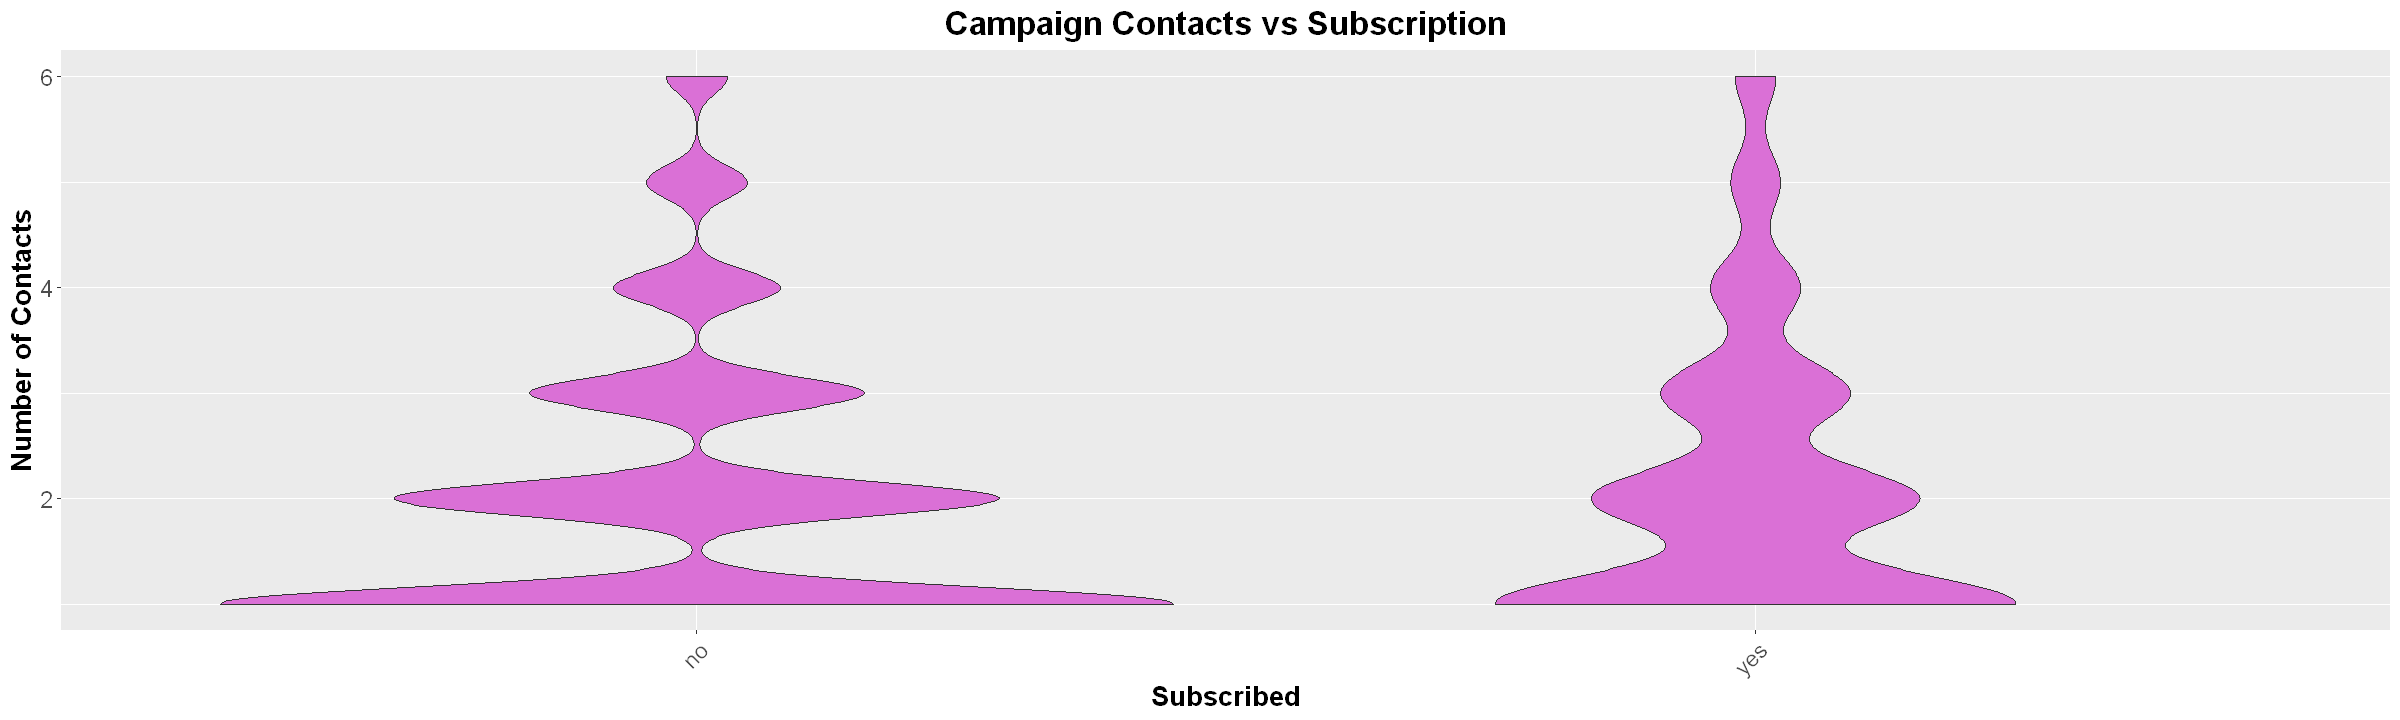

In [29]:
# Violin Plot
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = y, y = num_contacts)) +
  geom_violin(fill = "orchid") +
  labs(title = "Campaign Contacts vs Subscription", x = "Subscribed", y = "Number of Contacts") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Most individuals received fewer contacts, with distributions concentrated around 1–2 contacts for both subscription outcomes.
- Subscribed clients show slightly more spread, suggesting that multiple contacts may improve conversion likelihood.
- Non-subscribers are tightly clustered at low contact counts, indicating limited engagement.
- Increasing contact frequency could be explored as a strategy to boost subscription rates.

**Euribor Rate vs Subscription Outcome**

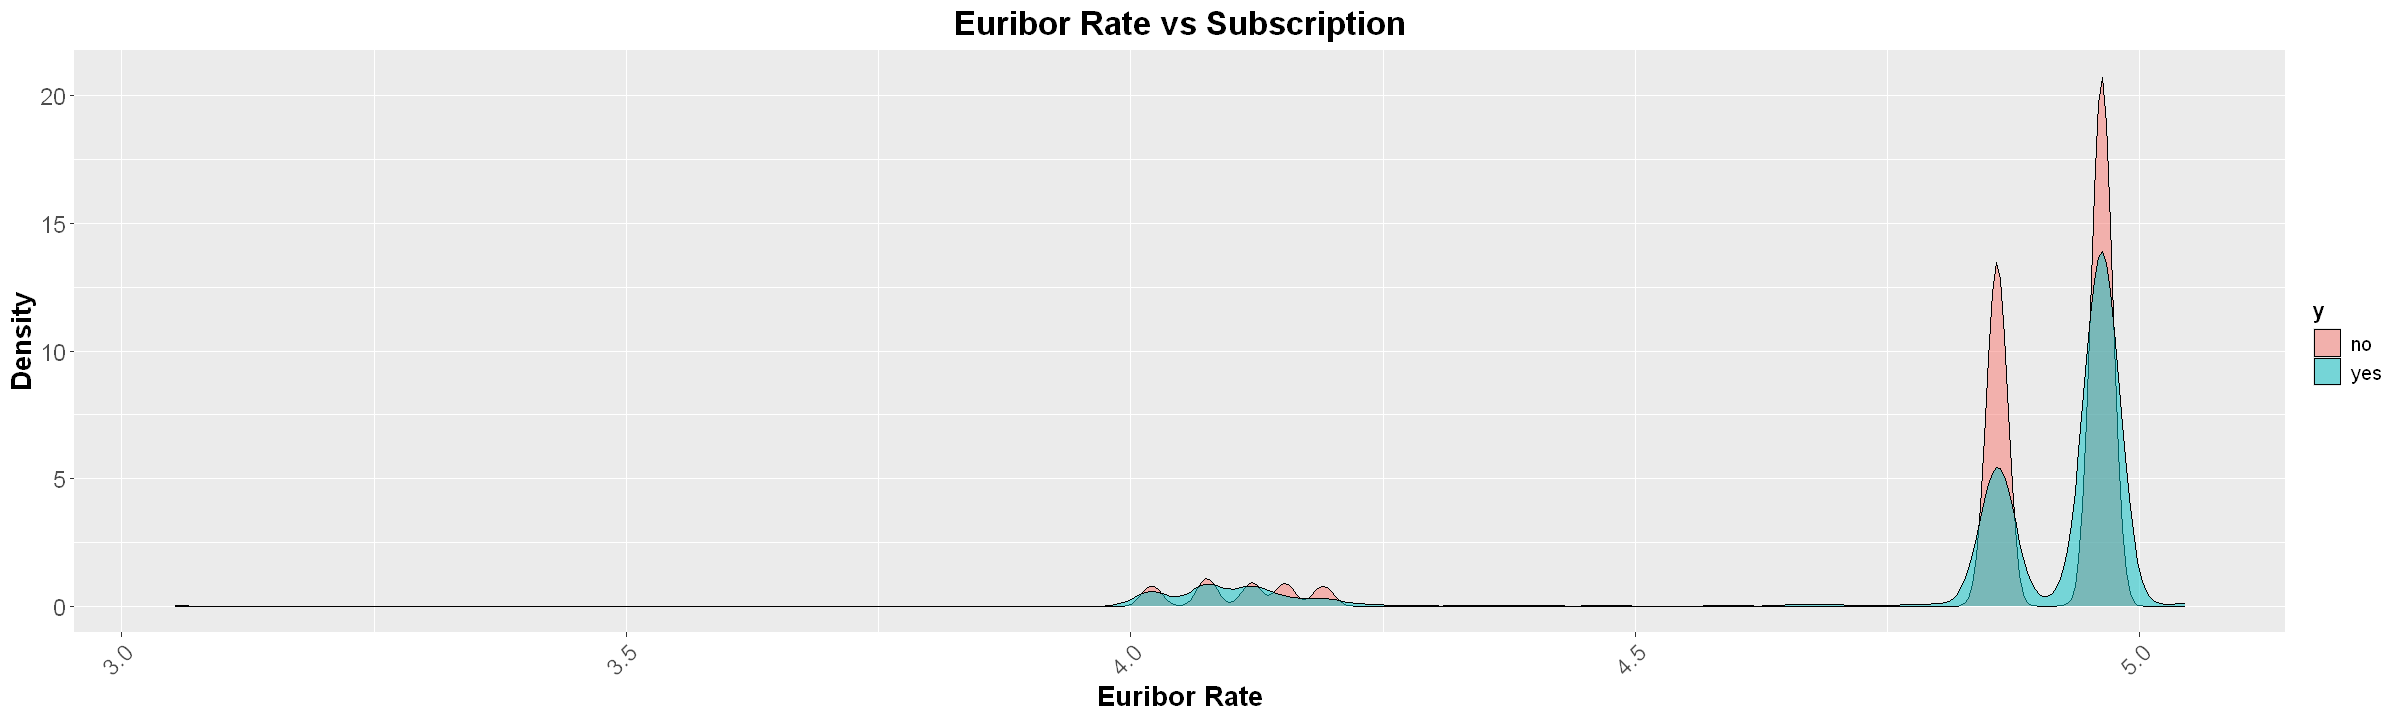

In [30]:
# Density Plot
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = euribor_rate, fill = y)) +
  geom_density(alpha = 0.5) +
  labs(title = "Euribor Rate vs Subscription", x = "Euribor Rate", y = "Density") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Subscriptions are more frequent at lower Euribor rates, as shown by the blue density peak on the left.
- Non-subscriptions dominate at higher Euribor rates, with a strong red peak on the right.
- Suggests that lower interest rates may encourage client engagement, possibly due to favorable financial conditions.

### Multivariate Analysis 

**Age vs Job Type vs Subscription Outcome**

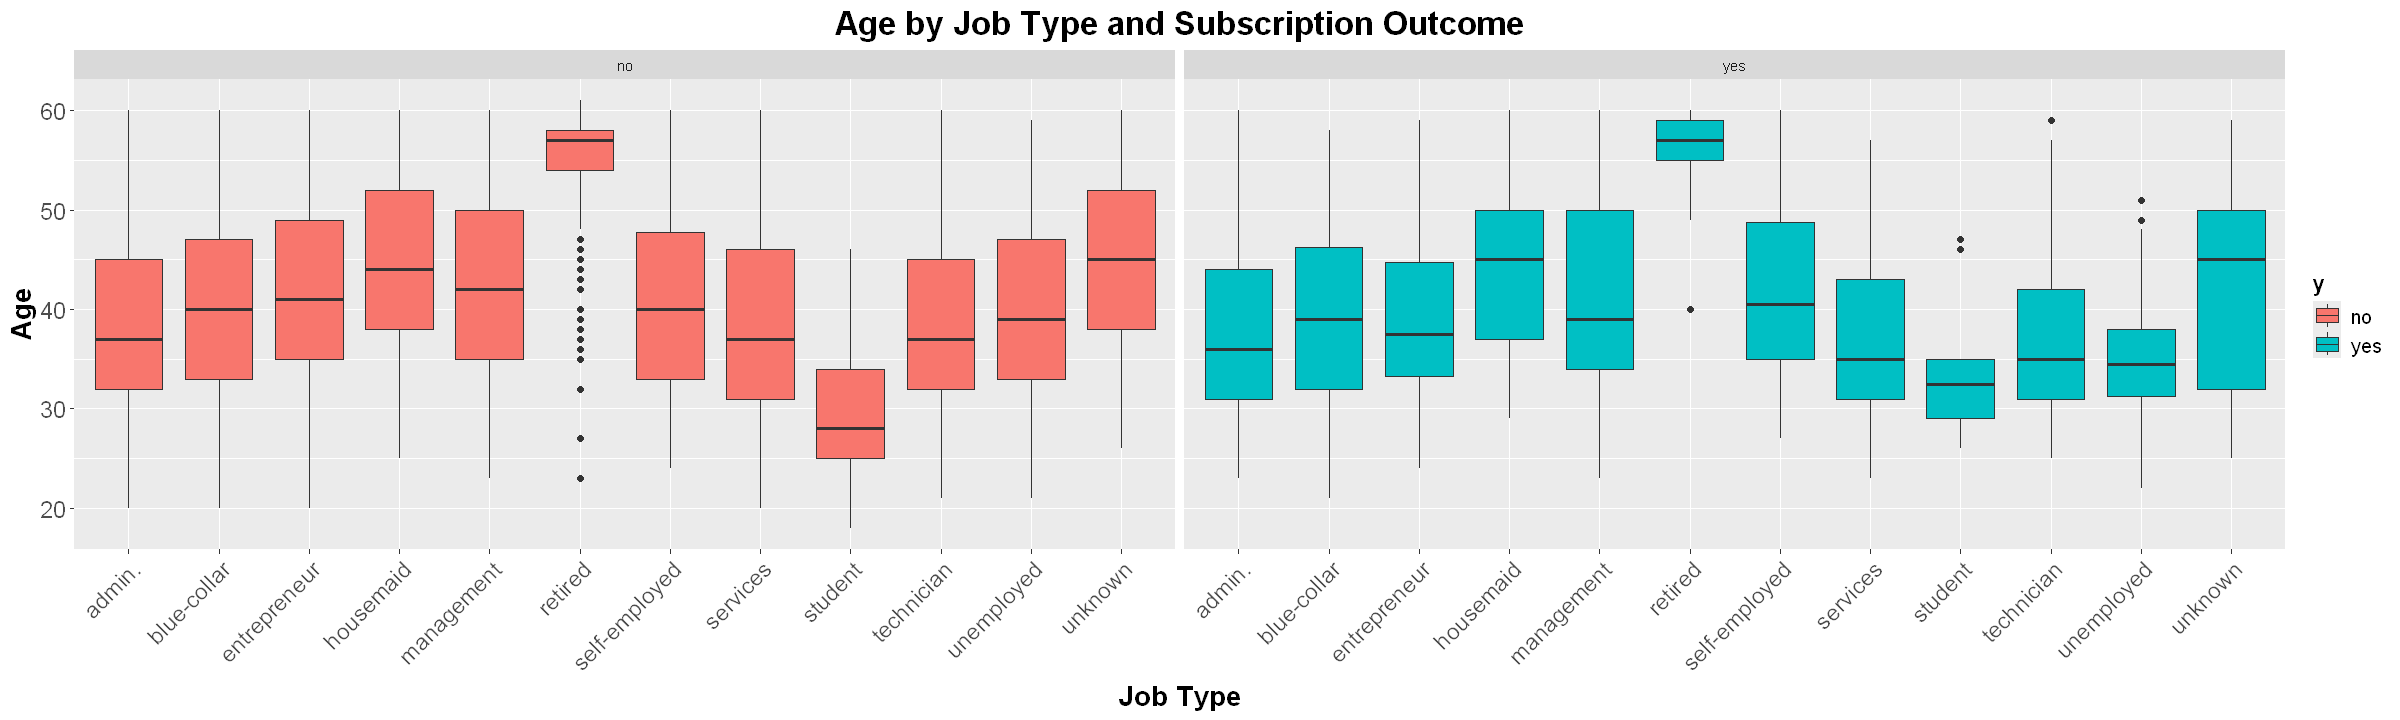

In [31]:
# Boxplot
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = job, y = age, fill = y)) +
  geom_boxplot() +
  facet_wrap(~ y) +
  labs(title = "Age by Job Type and Subscription Outcome", x = "Job Type", y = "Age") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Age distributions vary by job type, with some roles (e.g. retired, student) showing distinct age ranges.
- Retired individuals are consistently older, while students are younger, as expected.
- Subscribed clients tend to be slightly older in several job categories (e.g. technician, management), suggesting age may influence conversion.
- Outliers are present across most job types, especially among non-subscribers, indicating diverse age profiles.
- Combining age and job type offers strong segmentation potential for targeted marketing or predictive modeling.

**Education vs Marital Status vs Subscription**

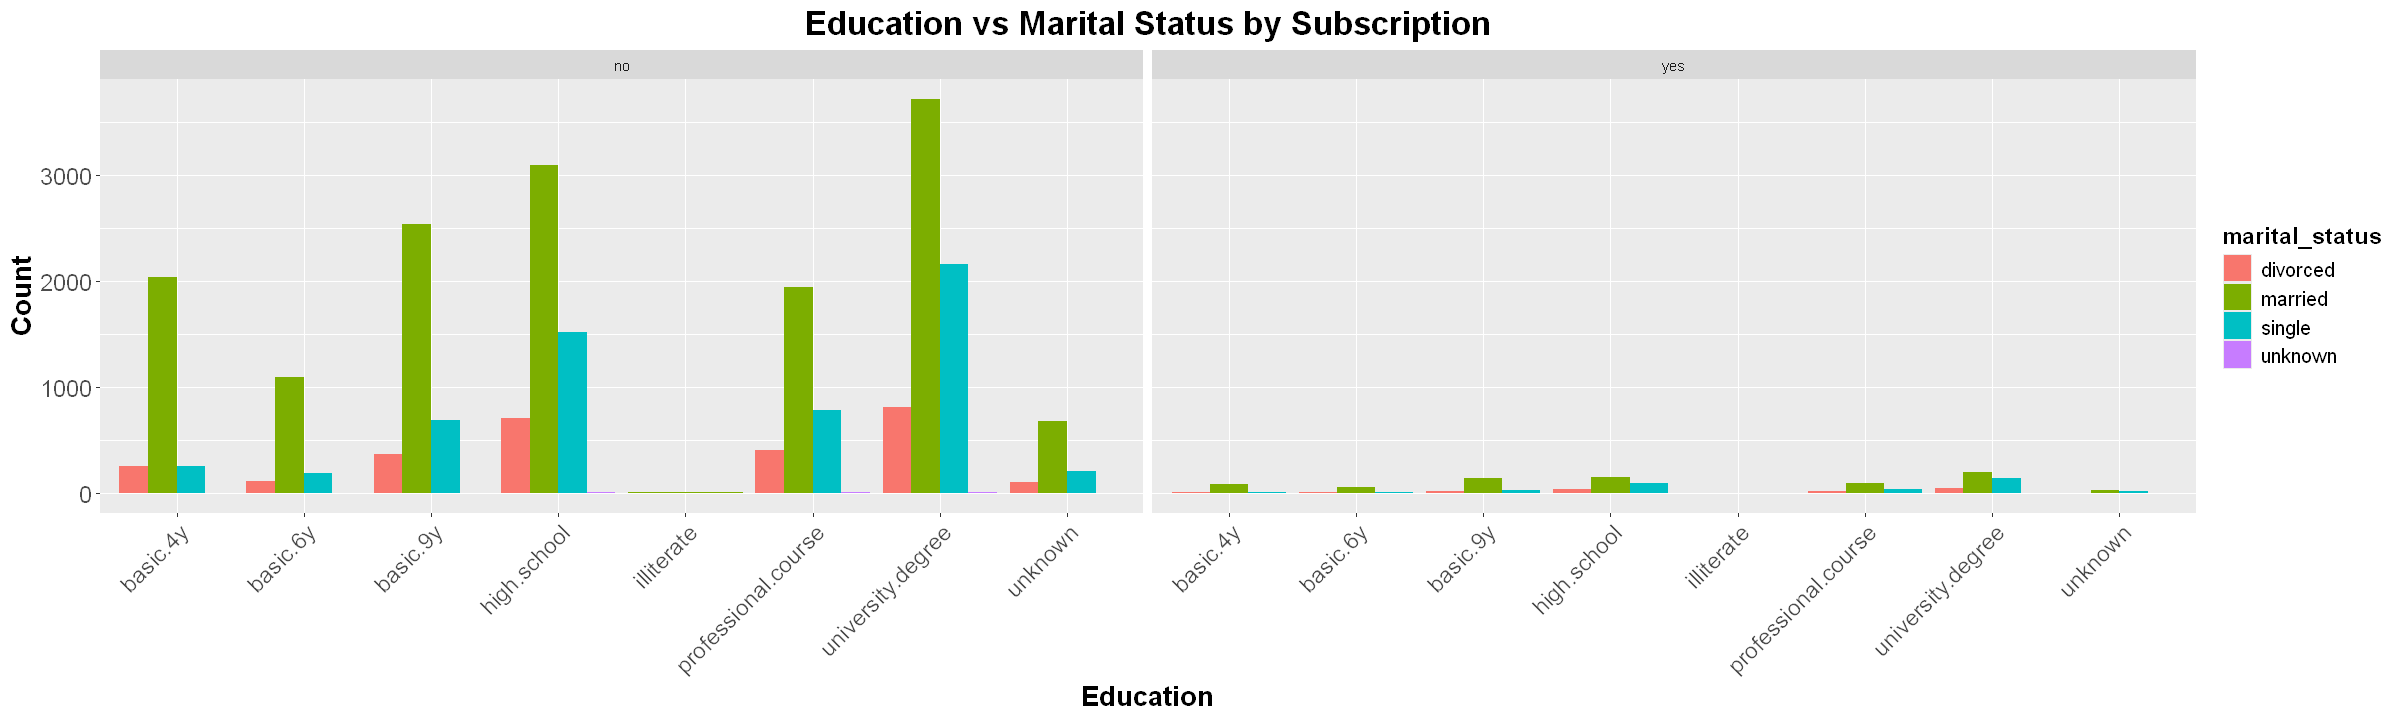

In [32]:
# Grouped Bar Chart with Fill
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = education_level, fill = marital_status)) +
  geom_bar(position = "dodge") +
  facet_wrap(~ y) +
  labs(title = "Education vs Marital Status by Subscription", x = "Education", y = "Count") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Married individuals dominate across all education levels, especially in the non-subscription group.
- Subscription counts are low across all combinations, with the highest drop-off among married clients with high school or university education.
- Single and divorced individuals show slightly better subscription rates, particularly in lower education tiers.
- Illiterate and unknown education levels have minimal representation*, but still follow the same pattern of low subscription.
- Education and marital status together offer valuable segmentation potential** for refining campaign targeting and messaging.

**Month vs Contact Type vs Subscription**

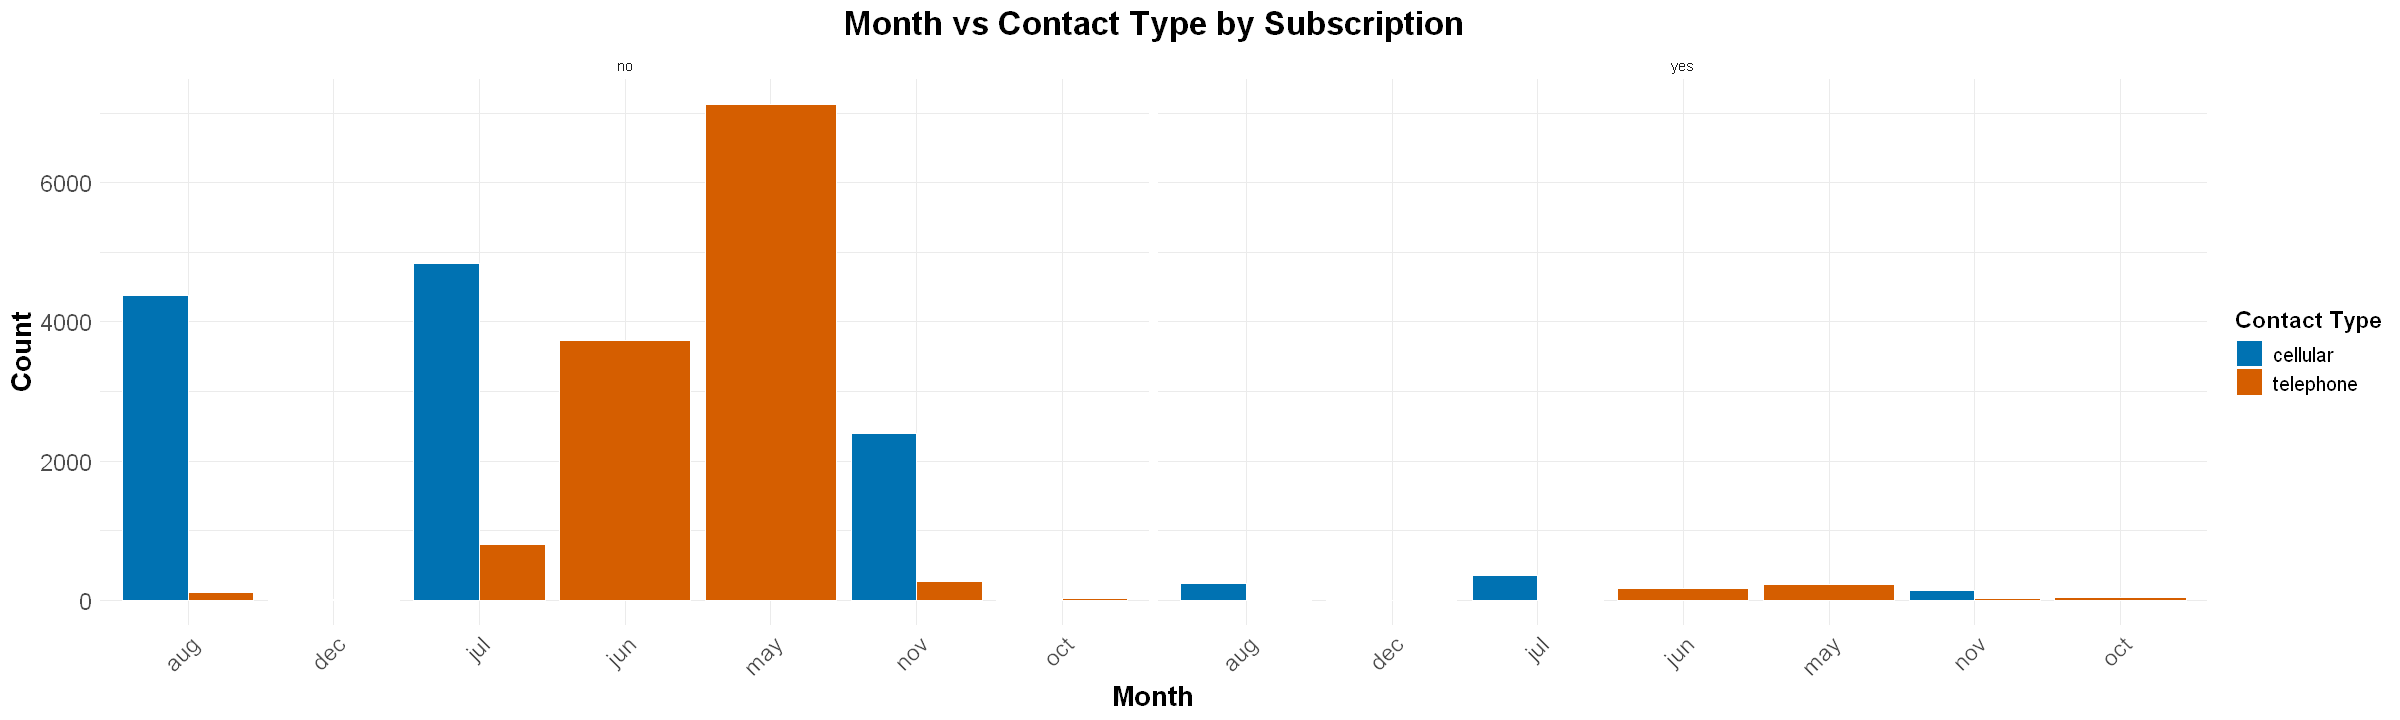

In [33]:
options(repr.plot.width = 20, repr.plot.height = 6)

month_contact <- data %>%
  count(month_of_contact, contact_type, y)

ggplot(month_contact, aes(x = month_of_contact, y = n, fill = contact_type)) +
  geom_bar(stat = "identity", position = "dodge", color = "white") +
  facet_wrap(~ y) +
  labs(title = "Month vs Contact Type by Subscription", x = "Month", y = "Count", fill = "Contact Type") +
  scale_fill_manual(values = c("cellular" = "#0072B2", "telephone" = "#D55E00")) +  # Color-blind safe
  theme_minimal() +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Telephone contacts peak in May, especially among non-subscribers indicating high outreach but low conversion.
- Cellular contacts are more evenly distributed, with notable activity in June and March across both subscription outcomes.
- Subscription rates are generally low across all months, regardless of contact type.
- Non-subscription dominates most months, suggesting contact method alone may not drive conversions.
- Combining contact type with timing and client segmentation could improve campaign targeting and effectiveness.

**Previous Campaign Outcome vs Number of Previous Contacts vs Subscription**

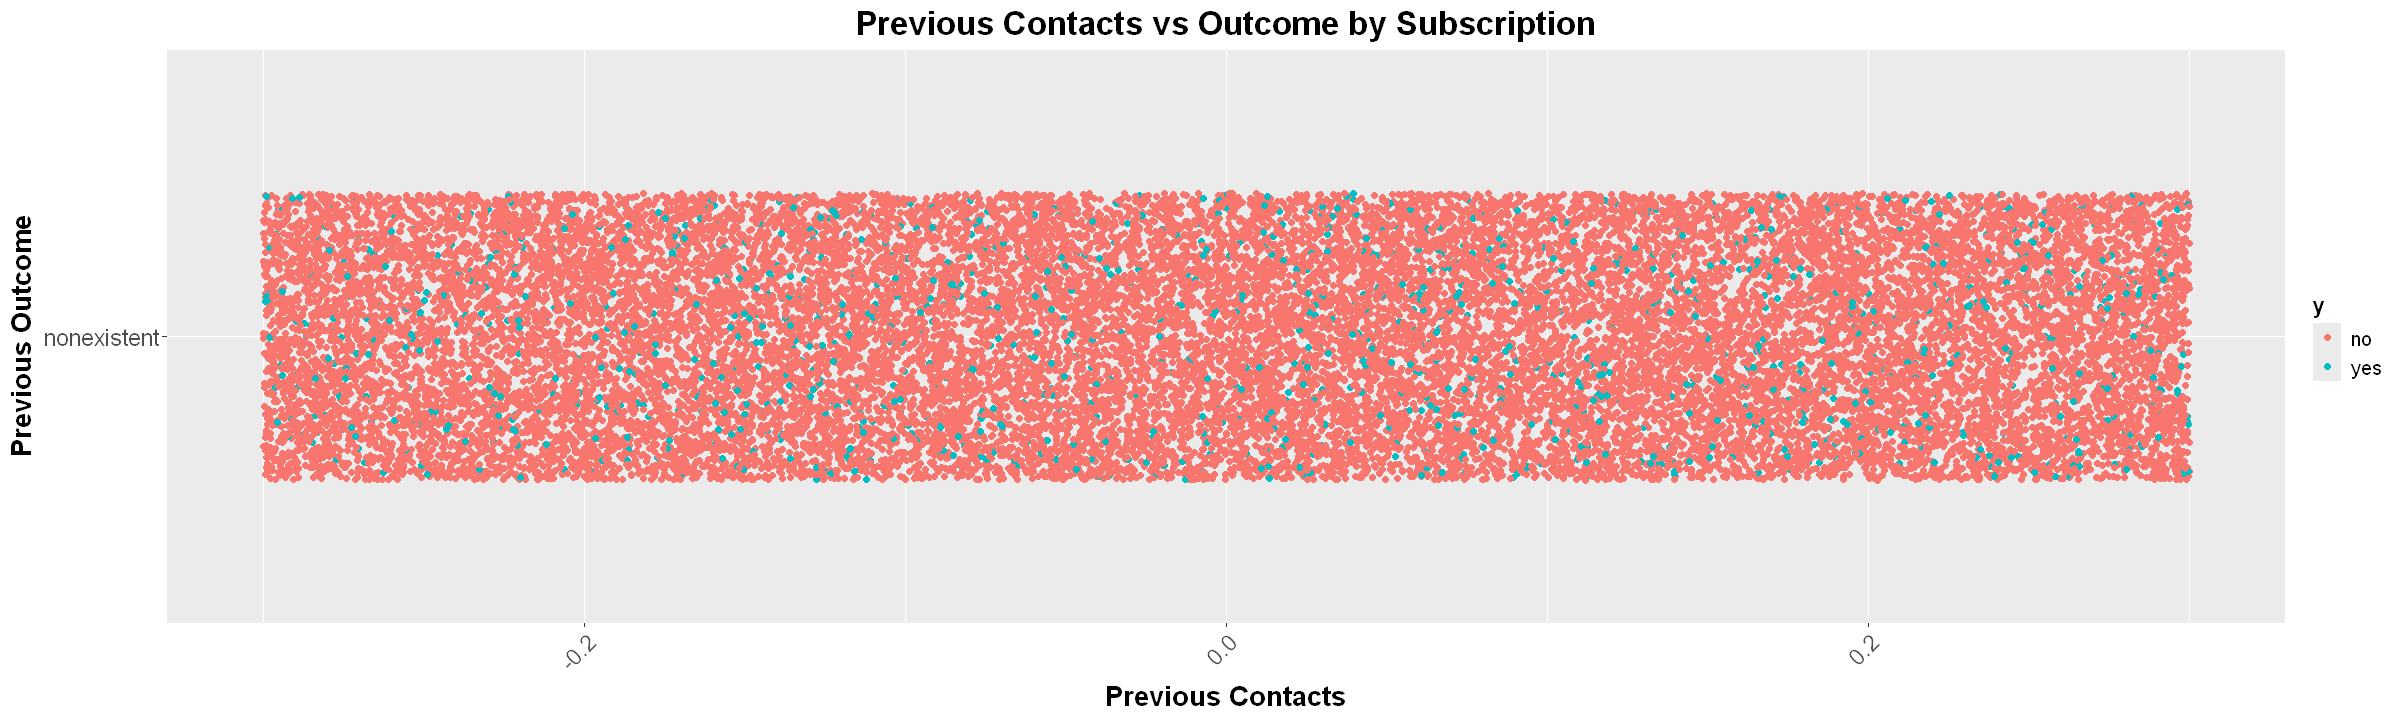

In [34]:
# Scatter Plot with Jitter
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = num_prev_contacts, y = prev_campaign_outcome, color = y)) +
  geom_jitter(width = 0.3, height = 0.3) +
  labs(title = "Previous Contacts vs Outcome by Subscription", x = "Previous Contacts", y = "Previous Outcome") +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Most clients with a nonexistent previous outcome did not subscribe, as shown by the dense cluster of red points.
- Subscribed clients (green) are fewer, but tend to have slightly more previous contacts suggesting persistence may help.
- Low contact counts dominate, indicating limited prior engagement across the board.
- Previous campaign outcome is a strong indicator, nonexistent history correlates with low subscription likelihood.

**Age vs Euribor Rate vs Subscription**

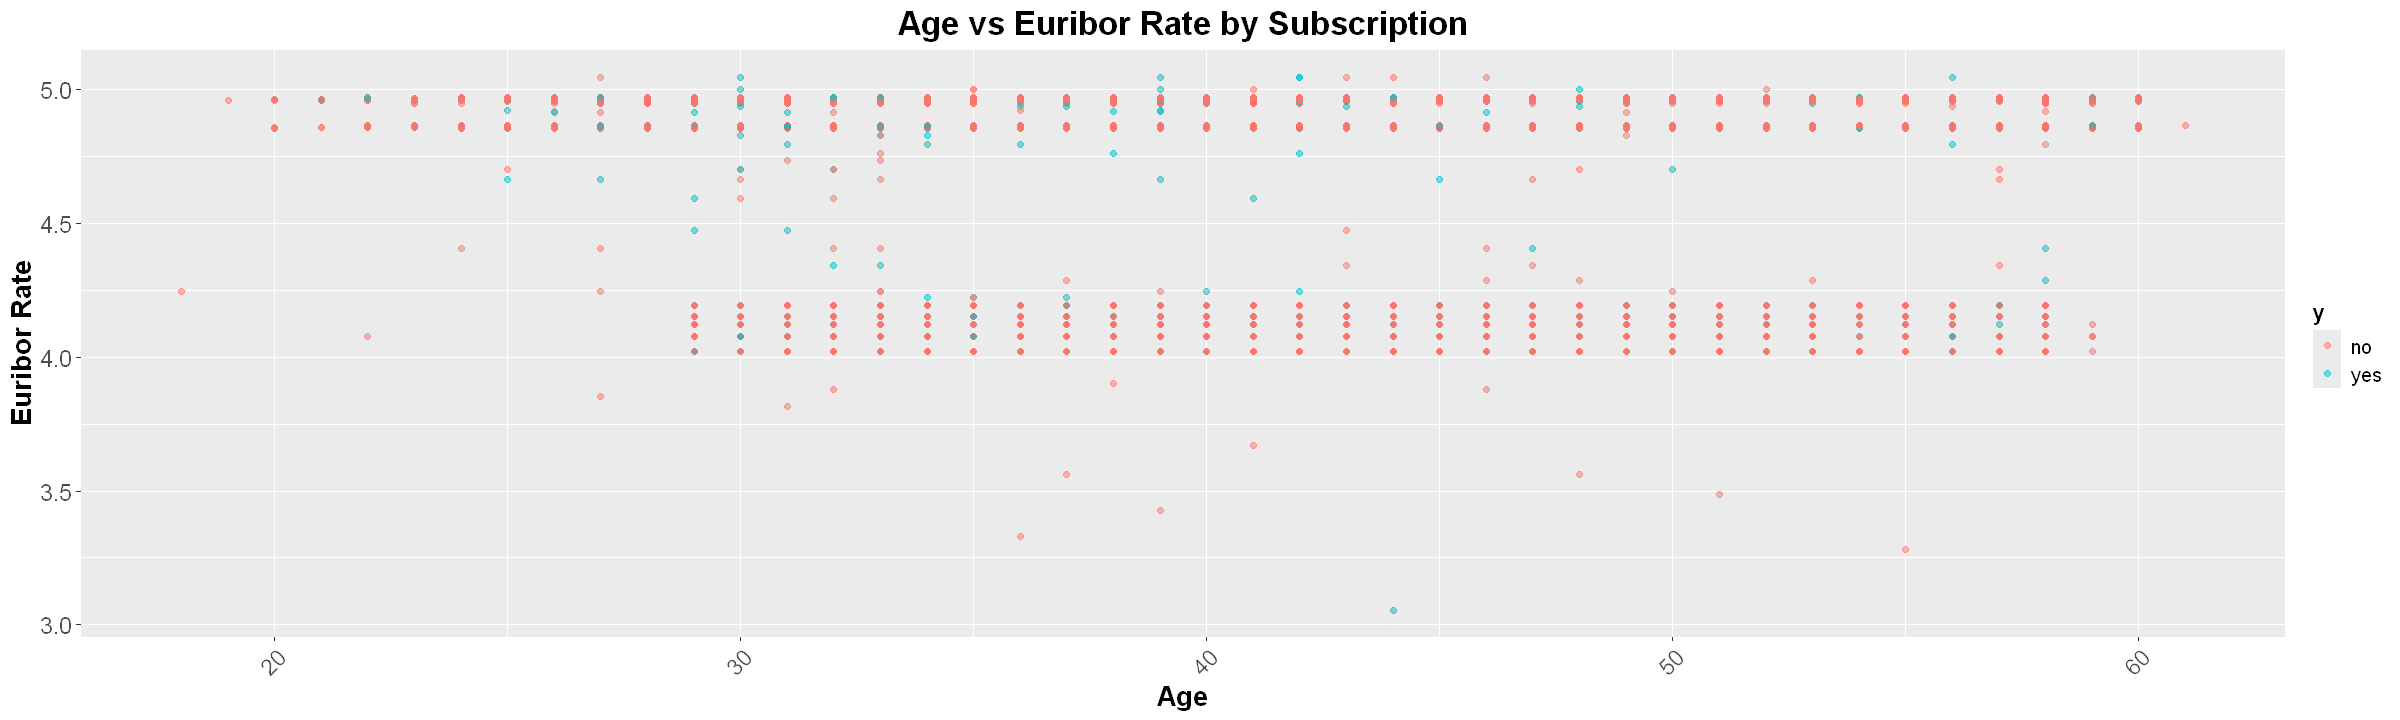

In [35]:
# Colored Scatter Plot
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = age, y = euribor_rate, color = y)) +
  geom_point(alpha = 0.5) +
  labs(title = "Age vs Euribor Rate by Subscription", x = "Age", y = "Euribor Rate") +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- Non-subscriptions cluster heavily around higher Euribor rates (≈ 4.8 – 4.9), regardless of age suggesting high rates deter engagement.
- Subscriptions are more frequent at lower Euribor rates, especially among middle-aged individuals.
- Age distribution is wide for both outcomes, but Euribor rate appears to be a stronger differentiator than age.
- Economic conditions (Euribor rate) likely influence subscription behavior more than demographic factors alone.
- Useful for timing campaigns: targeting lower-rate periods may improve conversion across age groups.

**Education vs Job vs Subscription**

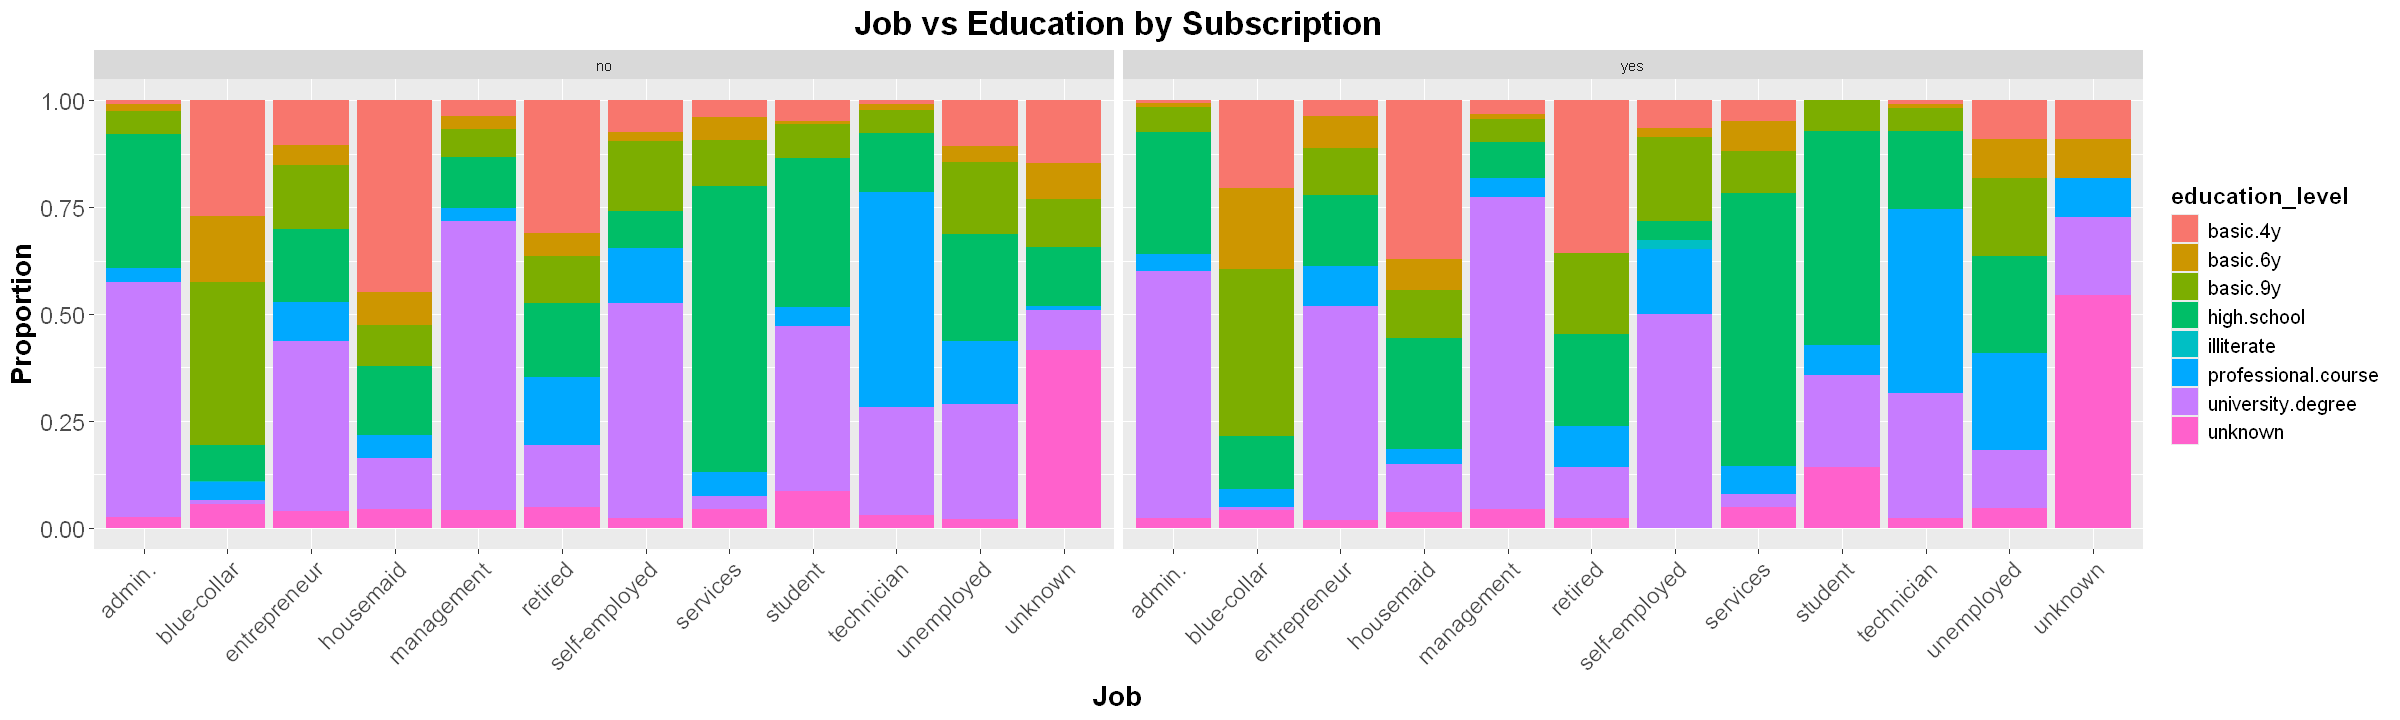

In [36]:
options(repr.plot.width = 20, repr.plot.height = 6)

ggplot(data, aes(x = job, fill = education_level)) +
  geom_bar(position = "fill") +
  facet_wrap(~ y) +
  labs(title = "Job vs Education by Subscription", x = "Job", y = "Proportion") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  theme(
    plot.title = element_text(size = 20, face = "bold", hjust = 0.5),
    axis.title.x = element_text(size = 16, face = "bold"),
    axis.title.y = element_text(size = 16, face = "bold"),
    axis.text.x  = element_text(size = 14, angle = 45, hjust = 1),
    axis.text.y  = element_text(size = 14),
    legend.text  = element_text(size = 12),
    legend.title = element_text(size = 14, face = "bold")
  )

- University degrees dominate among management, technician, and admin roles, especially in the non-subscription group.
- Blue-collar and housemaid roles show higher proportions of basic education levels, with minimal subscription success.
- Subscribed clients tend to have higher education levels, particularly in professional and student roles.
- Illiterate and unknown education levels are rare across all jobs, with limited impact on subscription outcomes.
- Education distribution varies significantly by job type useful for tailoring campaign messaging and segmentation.

### Correlation Analysis

***Numeric Features vs Target (y)***

In [37]:
# Using point-biserial correlation or comparing means with boxplots and t-tests.
numeric_cols <- c("age", "num_contacts", "days_since_last_contact", "num_prev_contacts",
                  "employment_rate", "consumer_price_index", "consumer_confidence_index",
                  "euribor_rate", "num_employees")

# Convert target to binary (1 = yes, 0 = no)
data$y_binary <- ifelse(data$y == "yes", 1, 0)

# Correlation matrix
cor_results <- corr.test(data[, numeric_cols], data$y_binary)
cor_results$r  # correlation coefficients
cor_results$p  # p-values

Warning message in cor(x, y, use = use, method = method):
"the standard deviation is zero"


age,-0.018092195
num_contacts,0.002074786
days_since_last_contact,NA
num_prev_contacts,NA
employment_rate,-0.020842691
consumer_price_index,-0.024092736
consumer_confidence_index,-0.039776100
euribor_rate,-0.002775235
num_employees,0.030352553


age,4.289075e-03
num_contacts,7.432863e-01
days_since_last_contact,NA
num_prev_contacts,NA
employment_rate,1.000564e-03
consumer_price_index,1.426193e-04
consumer_confidence_index,3.361262e-10
euribor_rate,6.613351e-01
num_employees,1.649271e-06


*Negative correlations*:
  - `consumer_confidence_index (-0.0398)`: lower confidence linked to higher subscription likelihood.
  - `consumer_price_index (-0.0241)`: lower prices slightly favor subscriptions.
  - `employment_rate (-0.0208)`: lower employment rate weakly associated with subscriptions.
  - `age (-0.0181)`: younger individuals slightly more likely to subscribe.
  - `euribor_rate (-0.0028)`: lower interest rates mildly favor subscriptions.

*Positive correlations*:
  - `num_employees (0.0304)`: larger workforce slightly linked to higher subscriptions.
  - `num_contacts (0.0021)`: minimal effect, but more contacts may help.

`days_since_last_contact` and `num_prev_contacts` were excluded due to missing values.

*Significant predictors (p-values)*:
  - `num_contacts (p ≈ 0.743)`: not significant, despite positive direction.
  - `euribor_rate (p ≈ 0.661)`: not significant, though direction aligns with earlier visual insights.
  - `consumer_confidence_index (p ≈ 3.36e-10)`: highly significant, strongest signal in the dataset.
  - `employment_rate`, `age`, and `consumer_price_index`: weak significance, p-values near 0.001–0.004.
  - `num_employees (p ≈ 1.65e-06)`: statistically significant but very weak correlation.

*Summary*
- Consumer confidence index is the most statistically significant predictor of subscription.
- Economic indicators (confidence, prices, employment) show stronger influence than personal demographics.
- Contact frequency and age have weak but directionally consistent effects.

Warning message in cor(data[, numeric_cols], use = "complete.obs"):
"the standard deviation is zero"


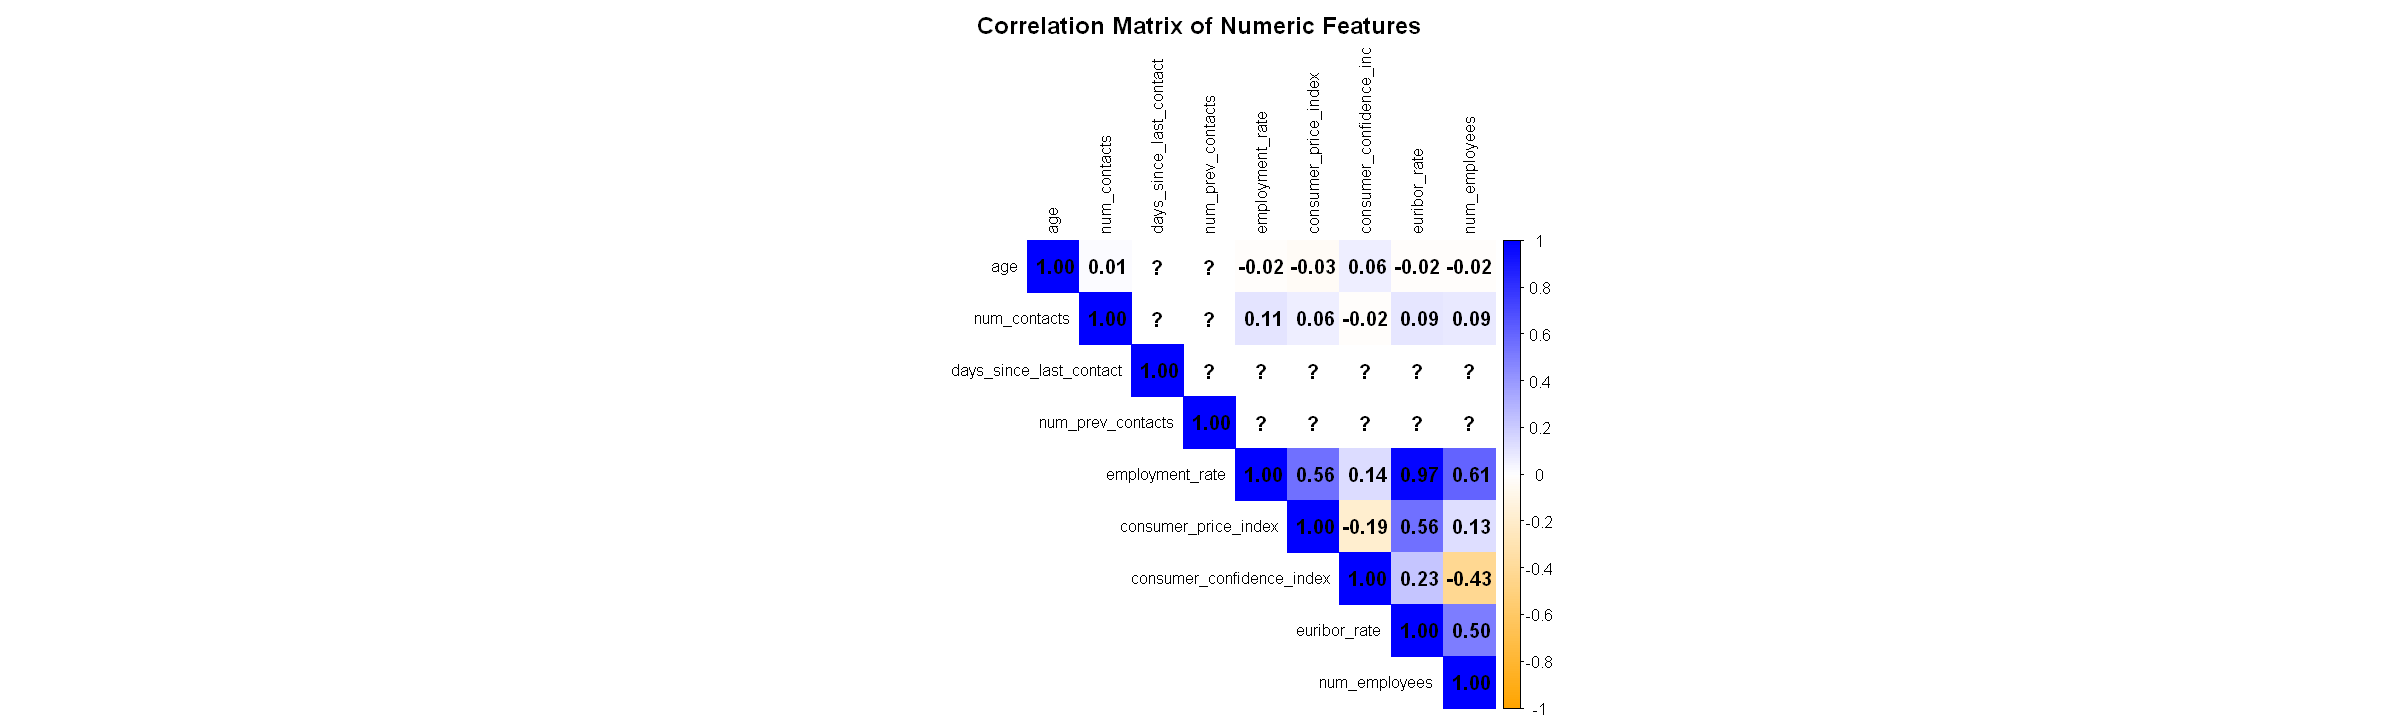

In [38]:
options(repr.plot.width = 20, repr.plot.height = 6)

# Compute correlation matrix
cor_matrix <- cor(data[, numeric_cols], use = "complete.obs")

# Visualize with corrplot
corrplot(cor_matrix,
         method = "color",
         type = "upper",
         tl.cex = 0.8,
         tl.col = "black",
         addCoef.col = "black",
         col = colorRampPalette(c("orange", "white", "blue"))(200),
         title = "Correlation Matrix of Numeric Features",
         mar = c(0, 0, 2, 0))  # Adjust margins to show title

In [39]:
library(vcd)  # for assocstats

# List of categorical features to test
cat_features <- c("job", "marital_status", "education_level", "has_default", "has_housing_loan", "has_personal_loan",
                  "contact_type", "month_of_contact", "day_of_week_contact", "prev_campaign_outcome")

# Fill NA values with "unknown" for all selected categorical features
data[cat_features] <- lapply(data[cat_features], function(x) {
  x[is.na(x)] <- "unknown"
  return(as.factor(x))  # ensure factors for table()
})

# Function to run Chi-square and Cramér’s V
analyze_categorical <- function(var) {
  tbl <- table(data[[var]], data$y)
  chi <- chisq.test(tbl)
  cramers_v <- assocstats(tbl)$cramer
  data.frame(
    Feature = var,
    Chi_Square = round(chi$statistic, 3),
    df = chi$parameter,
    p_value = round(chi$p.value, 4),
    Cramers_V = round(cramers_v, 3)
  )
}

# Apply to all features
results <- do.call(rbind, lapply(cat_features, analyze_categorical))
print(results)

Warning message in chisq.test(tbl):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(tbl):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(tbl):
"Chi-squared approximation may be incorrect"
Warning message in chisq.test(tbl):
"Chi-squared approximation may be incorrect"


                         Feature Chi_Square df p_value Cramers_V
X-squared                    job     11.155 11  0.4304     0.021
X-squared1        marital_status     10.495  3  0.0148     0.021
X-squared2       education_level     11.202  7  0.1301     0.021
X-squared3           has_default      4.328  2  0.1149     0.013
X-squared4      has_housing_loan      2.716  2  0.2572     0.010
X-squared5     has_personal_loan      2.532  2  0.2820     0.010
X-squared6          contact_type     49.902  1  0.0000     0.045
X-squared7      month_of_contact    544.738  6  0.0000     0.148
X-squared8   day_of_week_contact      9.006  4  0.0610     0.019
X-squared9 prev_campaign_outcome  20231.037  1  0.0000       NaN


**Statistically Significant Associations (p < 0.05)**
- month_of_contact (Cramér’s V = 0.148): Strongest association with subscription outcome, timing matters.
- contact_type (Cramér’s V = 0.045): Cellular vs telephone shows meaningful impact on conversion.
- marital_status (Cramér’s V = 0.021): Weak but statistically significant, singles may respond differently than married clients.
- prev_campaign_outcome: Extremely strong association (p < 0.0001), but Cramér’s V not computed — prior success is a key predictor.

**Weak or Non-Significant Associations**
- job, education_level, has_default, has_housing_loan, has_personal_loan, day_of_week: all show low Cramér’s V (< 0.021) and non-significant p-values, suggesting minimal standalone predictive power.

## Conclusion
The exploratory data analysis indicates that demographic features such as age, job type, marital status, and education level, along with economic indicators like Euribor rate, significantly influence subscription decisions. Campaign-related variables like the number of contacts and timing also impact response rates. While ML models were not developed here, the insights suggest that including attributes like job, education, Euribor rate, and campaign history will be crucial for accurate predictions.

### Insights
- Subscription rates are higher among middle-aged, married, and educated clients.
- Lower Euribor rates correlate with increased client engagement.
- Campaign variables such as the number of contacts and contact month influence subscription likelihood.
- Outliers and diverse age distributions should be considered, as some groups (retired, students) behave differently.

### Recommendations
- Focus marketing efforts on clients with favorable demographics and during periods of low Euribor rates.
- Prioritize features like job, education, and campaign history in building predictive models.
- Use targeted campaigns during months identified with higher subscription propensities.

### Limitations
- This analysis is limited to exploratory insights actual predictive performance requires ML modeling.
- Missing or "unknown" categorical data may obscure some relationships if not properly handled.
- The current dataset may lack behavioral or psychographic data to fully capture customer motivations.

### Future Work
- Implement and evaluate classification algorithms (e.g., logistic regression, Random Forest, SVM) to build an effective predictive model.
- Conduct feature importance analysis with ML techniques to refine feature selection.
- Explore temporal and regional factors for dynamic and location-based strategies.
- Address data imbalance and missing values for improved model robustness.